In [1]:
# ─── Imports & Global Configuration ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import pickle
import importlib
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Image as IPImage, Markdown

# ── Colour palette (consistent across all charts) ─────────────────────────────
BLUE   = '#2196F3'
GREEN  = '#4CAF50'
ORANGE = '#FF9800'
RED    = '#F44336'
BLACK  = '#212121'
GRAY   = '#9E9E9E'

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR  = Path('data/processed')
OOS_DIR   = DATA_DIR / 'rolling_oos'
NOTES_DIR = Path('notes')
FIG_DIR   = NOTES_DIR / 'notebook_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Matplotlib / seaborn style ────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Helpers ───────────────────────────────────────────────────────────────────
def load_pkl(path):
    """Load a PKL file. Returns None with a warning if not found."""
    p = Path(path)
    if not p.exists():
        print(f'WARNING: PKL not found: {p} -- section skipped')
        return None
    with open(p, 'rb') as fh:
        return pickle.load(fh)

def save_fig(fig, name):
    """Save figure to notes/notebook_figures/."""
    fp = FIG_DIR / f'{name}.png'
    fig.savefig(fp, dpi=150, bbox_inches='tight')
    print(f'   Figure saved -> {fp}')

# Pre-load PKLs used across multiple sections so we fail fast
wf   = load_pkl(DATA_DIR / 'walk_forward_results.pkl')
dist = load_pkl(DATA_DIR / 'walk_forward_distillation_results.pkl')
oos  = load_pkl(OOS_DIR  / 'rolling_oos_quarterly_results.pkl')

best_T  = dist['best_T'] if dist is not None else None
ebm_col = f'EBM AUC (T={best_T})' if best_T is not None else 'EBM AUC'

# Placeholders for values computed later
bh_total = bh_sharpe = bh_mdd = float('nan')
df_is    = None
df_spy   = None

print('Imports complete -- notebook ready')
print(f'  Working directory : {Path(".").resolve()}')
print(f'  Figure output     : {FIG_DIR}')
print(f'  Best distill T    : {best_T}')

Imports complete -- notebook ready
  Working directory : C:\Users\M333209\OneDrive - MerckGroup\Escritorio\TFM\Code
  Figure output     : notes\notebook_figures
  Best distill T    : 2


In [2]:
from IPython.display import HTML as _HTML
display(_HTML("""
<style>
  div.input  { display: none !important; }
  div.prompt { display: none !important; }
  .jp-CodeCell .jp-Cell-inputWrapper { display: none !important; }
  .jp-InputPrompt { display: none !important; }
</style>
"""))

---
# Binary Classification of SPY Daily Returns using Machine Learning
### Master's Thesis (TFM) — Results Notebook

**Date:** 2026-05-05 &nbsp;|&nbsp; **Asset:** SPY ETF (S&P 500) &nbsp;|&nbsp; **Period:** 2004–2024 &nbsp;|&nbsp; **Repository:** [github.com/paulacarbajo/TFM](https://github.com/paulacarbajo/TFM)

---

This notebook presents the full results of a supervised machine learning pipeline for **predicting the daily direction of the S&P 500 index** (SPY ETF). Labels are generated via the **Triple Barrier Method** — each observation is labeled +1 (take profit) or −1 (stop loss / time barrier) using a maximum holding period of 8 days and a volatility-scaled barrier of ×1.0. Model validation uses **walk-forward cross-validation** (3-year rolling training window, 1-year validation window) to prevent look-ahead bias.

The pipeline explores a **knowledge distillation chain** with three parallel branches from a common teacher:
- **LightGBM** (teacher): complex gradient-boosted ensemble
- **EBM Primary** (Tier 2a): interpretable GAM trained directly on hard labels — no distillation
- **EBM Distilled** (Tier 2b): interpretable GAM trained on LightGBM soft labels via temperature scaling
- **RuleFit** (Tier 3): human-readable if-then rules trained on LightGBM soft labels directly

Two iterations are evaluated: **Iteration 1** uses 10 pure technical features; **Iteration 2** adds 3 GMM-based market regime features. The **out-of-sample (OOS) period is 2020–2024** (20 quarterly folds, never seen during in-sample development).

---
## Section 2 — Data & Labeling

**Data source:** Yahoo Finance (SPY OHLCV, 2004–2024, ~5,284 trading days). VIX volatility index from FRED (VIXCLS) used as GMM regime input only.

**Triple Barrier Method** (López de Prado, 2018): for each observation, three exit barriers are set simultaneously:
- **Upper barrier** (take profit): price rise of +1.0 × 20-day EWM volatility
- **Lower barrier** (stop loss): price fall of −1.0 × 20-day EWM volatility
- **Vertical barrier** (time limit): 8 trading days maximum holding period

**Binary label:** `+1` = take profit barrier hit first; `−1` = stop loss or time barrier hit first.

> **Note on data coverage:** The descriptive statistics below cover the full 2004–2024 dataset. However, the model is only trained and evaluated from 2008 onwards — the 2004–2007 period serves as a warm-up buffer to ensure all technical indicators are fully stabilised before the first training fold begins. This does not introduce any bias.

In [3]:
# ─── Load engineered features ─────────────────────────────────────────────────
h5_path = DATA_DIR / 'assets.h5'
if not h5_path.exists():
    print(f'WARNING: {h5_path} not found -- Section 2 cells skipped')
else:
    df_all = pd.read_hdf(h5_path, key='engineered_features')
    if isinstance(df_all.index, pd.MultiIndex):
        df_all = df_all.reset_index()
    df_spy = df_all[df_all['ticker'] == 'SPY'].copy()
    df_spy['date'] = pd.to_datetime(df_spy['date'])
    df_spy = df_spy.set_index('date').sort_index()
    df_spy['daily_return'] = df_spy['Close'].pct_change()
    print(f'SPY observations : {len(df_spy):,}  (full dataset 2004–2024)')
    print(f'Date range       : {df_spy.index.min().date()} -> {df_spy.index.max().date()}')
    print()

    # ── Descriptive statistics table ──────────────────────────────────────────
    _stat_cols = {
        'Close':        'SPY Close Price ($)',
        'daily_return': 'Daily Return',
        'vol_20d':      '20-day EWM Volatility',
    }
    _stats_rows = []
    for col, label in _stat_cols.items():
        if col in df_spy.columns:
            s = df_spy[col].dropna()
            _stats_rows.append({
                'Variable': label,
                'Mean':     f'{s.mean():.4f}',
                'Std Dev':  f'{s.std():.4f}',
                'Min':      f'{s.min():.4f}',
                'Max':      f'{s.max():.4f}',
                'N Obs':    f'{len(s):,}',
            })
    _df_stats = pd.DataFrame(_stats_rows).set_index('Variable')
    display(
        _df_stats.style
        .set_caption('Table 1 — SPY Descriptive Statistics (full dataset 2004–2024)')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-weight', 'bold'), ('font-size', '13px')]}])
    )
    display(Markdown(
        "> **Note:** Statistics cover the full available dataset (2004–2024). "
        "The 2004–2007 period is used exclusively as a **warm-up buffer** to allow "
        "technical indicators (e.g. 60-day volatility, MACD) to stabilise before the "
        "first training fold begins in 2008. No model is trained or evaluated on this period."
    ))

SPY observations : 5,284  (full dataset 2004–2024)
Date range       : 2004-01-02 -> 2024-12-30



,Mean,Std Dev,Min,Max,N Obs
Variable,,,,,
SPY Close Price ($),199.3538,132.3966,49.8086,597.1094,"5,284"
Daily Return,0.0005,0.0118,-0.1094,0.1452,"5,283"
20-day EWM Volatility,0.0098,0.0067,0.0022,0.0615,"5,282"


> **Note:** Statistics cover the full available dataset (2004–2024). The 2004–2007 period is used exclusively as a **warm-up buffer** to allow technical indicators (e.g. 60-day volatility, MACD) to stabilise before the first training fold begins in 2008. No model is trained or evaluated on this period.

   Figure saved -> notes\notebook_figures\fig1_spy_price_history.png


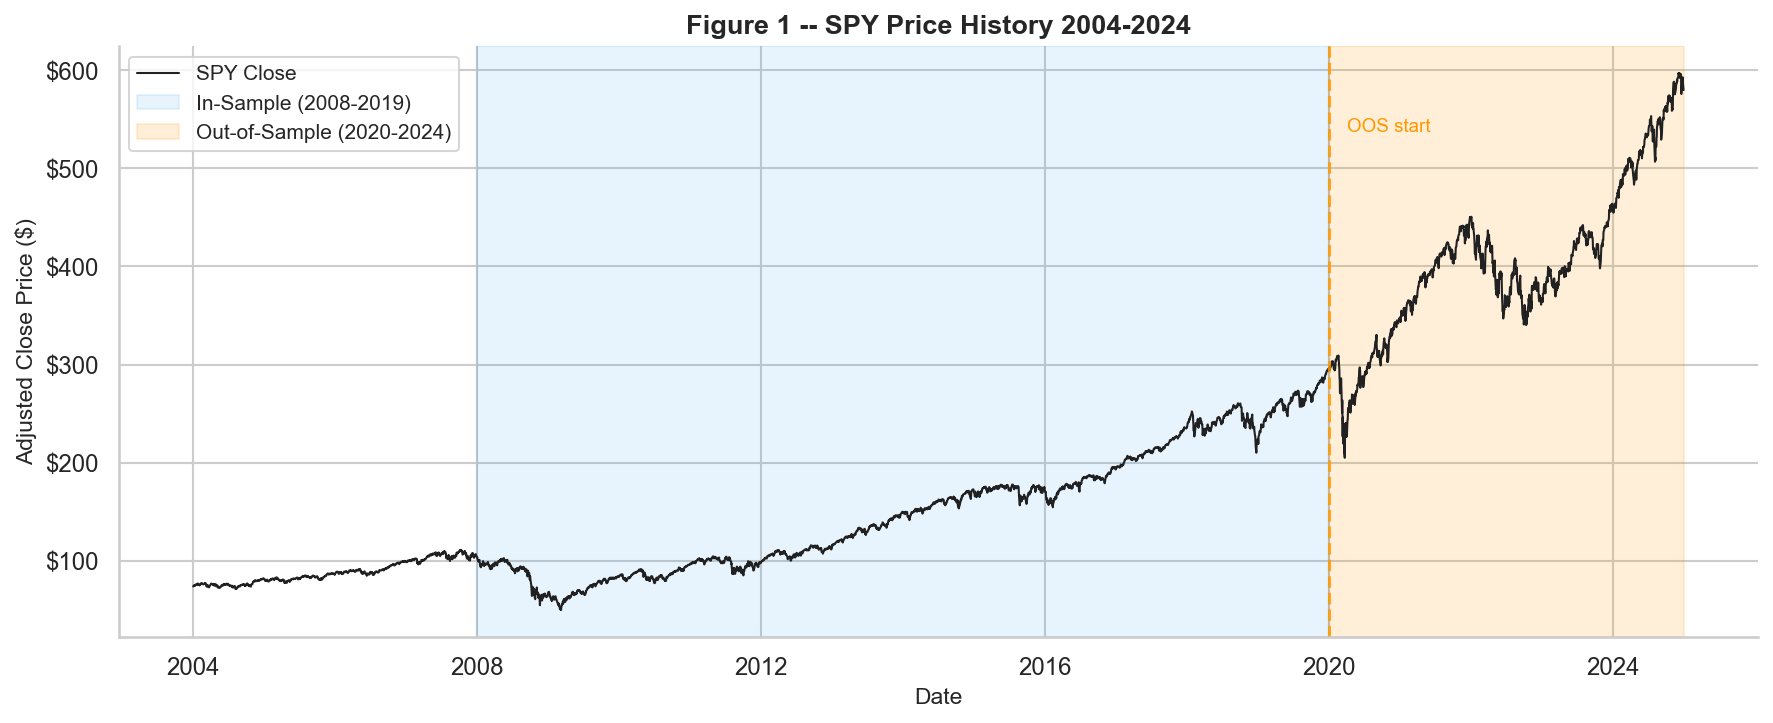

In [4]:
# ─── Figure 1: SPY Price History 2004-2024 ────────────────────────────────────
if df_spy is not None:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

    ax.plot(df_spy.index, df_spy['Close'], color=BLACK, linewidth=1.0, label='SPY Close')
    ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2019-12-31'),
               alpha=0.10, color=BLUE, label='In-Sample (2008-2019)')
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2024-12-31'),
               alpha=0.15, color=ORANGE, label='Out-of-Sample (2020-2024)')
    ax.axvline(pd.Timestamp('2020-01-01'), color=ORANGE, linewidth=1.5,
               linestyle='--', alpha=0.8)

    _ymax = df_spy['Close'].max()
    ax.text(pd.Timestamp('2020-04-01'), _ymax * 0.90, 'OOS start',
            color=ORANGE, fontsize=9)

    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Adjusted Close Price ($)', fontsize=11)
    ax.set_title('Figure 1 -- SPY Price History 2004-2024', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    plt.tight_layout()
    save_fig(fig, 'fig1_spy_price_history')
    plt.show()
else:
    print('INFO: df_spy not loaded -- price chart skipped')

> The blue shaded area covers the in-sample period used for model training and validation (2008–2019). The orange area is the out-of-sample backtest period (2020–2024), which was never used during development. Note the sharp drop in early 2020 (COVID crash) and the strong bull run through 2024 driven by post-COVID recovery and the AI boom.

   Figure saved -> notes\notebook_figures\fig2_label_distribution.png


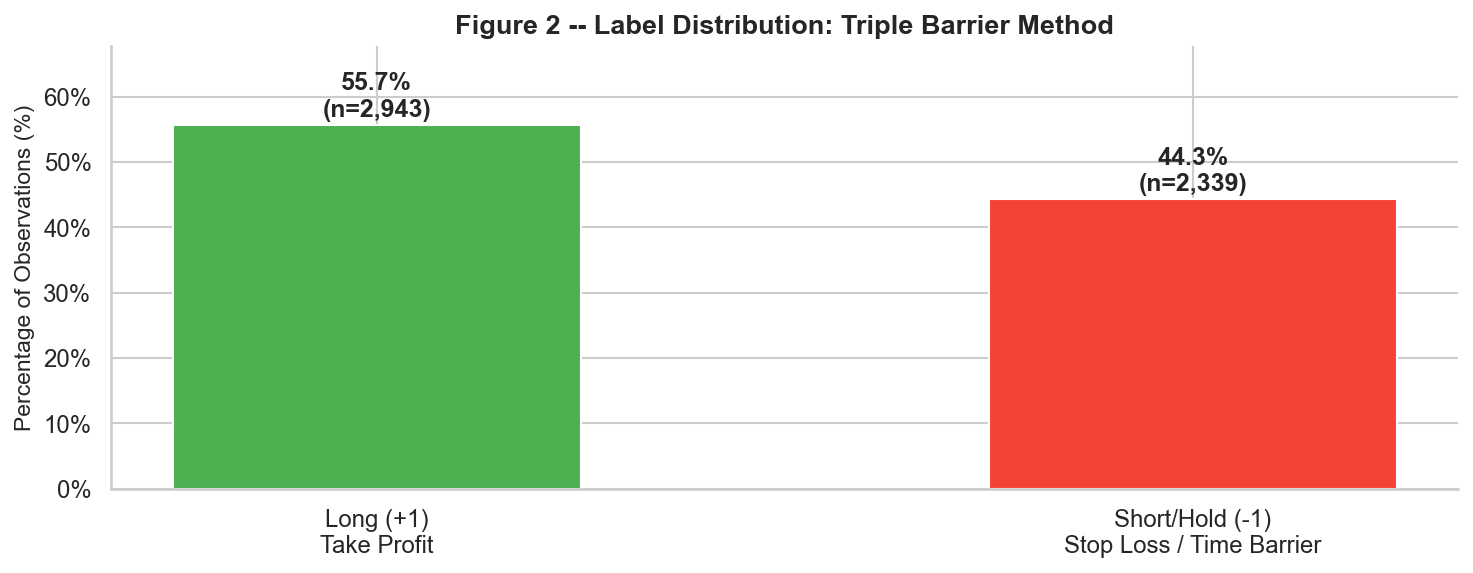

Labeled obs: 5,282 | Long: 2,943 (55.7%) | Short/Hold: 2,339 (44.3%)


In [5]:
# ─── Figure 2: Label Distribution ────────────────────────────────────────────
if df_spy is not None and 'label_binary' in df_spy.columns:
    _lbl = df_spy['label_binary'].dropna()
    _n_long  = (_lbl ==  1).sum()
    _n_short = (_lbl == -1).sum()
    _n_total = len(_lbl)
    _pct_long  = 100 * _n_long  / _n_total
    _pct_short = 100 * _n_short / _n_total

    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
    _bars = ax.bar(
        ['Long (+1)\nTake Profit', 'Short/Hold (-1)\nStop Loss / Time Barrier'],
        [_pct_long, _pct_short],
        color=[GREEN, RED], edgecolor='white', width=0.5
    )
    for bar, pct, n in zip(_bars, [_pct_long, _pct_short], [_n_long, _n_short]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{pct:.1f}%\n(n={n:,})', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.set_ylabel('Percentage of Observations (%)', fontsize=11)
    ax.set_title('Figure 2 -- Label Distribution: Triple Barrier Method',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(_pct_long, _pct_short) + 12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    save_fig(fig, 'fig2_label_distribution')
    plt.show()
    print(f'Labeled obs: {_n_total:,} | Long: {_n_long:,} ({_pct_long:.1f}%) | '
          f'Short/Hold: {_n_short:,} ({_pct_short:.1f}%)')
else:
    print('INFO: label_binary column not available -- chart skipped')

> The model predicts two outcomes: **+1** when the take-profit barrier is hit first (55.7 % of cases) and **−1** when the stop-loss or time barrier hits first (44.3 %). The slight imbalance toward long signals reflects the long-term upward drift of the S&P 500. Labels are sufficiently balanced that no additional resampling is needed beyond LightGBM's built-in `class_weight='balanced'` setting.

---
## Section 3 — Feature Set

Features are selected per fold using **IC (Information Coefficient) filtering**: Spearman rank correlation with the forward label, computed on the training slice only. Features with |IC| < 0.01 are dropped (minimum 6 features retained). This prevents using future data to select features.

### Iteration 1 — Pure Technical Features (10)

| Feature | Category | Description |
|---|---|---|
| `ret_5d` | Momentum | 5-day cumulative return |
| `ret_21d` | Momentum | 21-day cumulative return |
| `vol_rel` | Volatility | vol_20d / vol_60d — relative volatility ratio |
| `atr_14` | Volatility | Average True Range (14-day, normalised by Close) |
| `rsi_14` | Oscillator | Relative Strength Index (14-day) |
| `macd_line` | Trend | MACD line (12/26 EMA difference) |
| `macd_signal` | Trend | MACD signal line (9-day EMA of MACD line) |
| `bb_pct` | Bands | Bollinger %B — price position within Bollinger Bands |
| `bb_width` | Bands | Bollinger Band width — volatility proxy |
| `volume_direction` | Volume | Volume ratio × sign(ret_1d) — directional volume |

> All features are **stationary**. `vol_20d` is deliberately excluded because it directly determines the Triple Barrier barrier width, creating a mechanical correlation with the label.

### Iteration 2 — Adds 3 GMM Regime Features

| Feature | Description |
|---|---|
| `regime_state` | Discrete regime label: 0 = Bull (low vol), 1 = Bear (high vol) |
| `regime_prob_0` | GMM posterior probability of Bull regime |
| `regime_prob_1` | GMM posterior probability of Bear regime |

> The GMM is fitted **on training data only** per fold — both during the in-sample walk-forward and during each quarterly retraining in the OOS period — so there is no look-ahead bias at any stage. Regimes are ordered by volatility. `regime_state` was included as a candidate feature alongside the three probabilities, but SHAP analysis confirms it carries near-zero importance (≈ 0) — the model extracts all regime information from the continuous probabilities `regime_prob_0/1`, not from the discrete label.

---
## Section 4 — In-Sample Results (Walk-Forward 2008–2019)

Walk-forward CV uses a **3-year rolling training window** and **1-year validation window**, producing **9 folds** (2008–2019, baseline config). IC feature selection is applied per fold on the training slice only — the selected feature subset is then applied to the validation set.

**Metrics glossary:**
- **Accuracy:** proportion of correct directional predictions. Random baseline ≈ 0.50.
- **AUC (Area Under ROC Curve):** probability that the model ranks a positive case above a negative one. 0.50 = random; 1.0 = perfect. Supervisor target: 0.52–0.60.
- **F1 Score:** harmonic mean of precision and recall. Higher is better; accounts for class imbalance.
- **Brier Score:** mean squared error of predicted probabilities vs actual outcomes. Lower is better; 0.25 = uninformative model (always predicts 0.5).

**Table colour coding**
**AUC:**
- Green = AUC > 0.52 (above supervisor target)
- Red = AUC < 0.50 (below random baseline — worse than chance)
- No colour = AUC between 0.50 and 0.52 (above random but below target)
- Mean row in **bold darker green** if mean AUC > 0.52

**Accuracy (Mean row only):**
- Green = Accuracy > 0.52 (above random baseline)

**F1 Score (Mean row only):**
- Green = F1 > 0.58 (good balance between precision and recall)
- Yellow = F1 0.53–0.58 (acceptable)
- No colour = F1 < 0.53

**Brier Score** (lower is better):
- Green = Brier < 0.28 (well calibrated, better than baseline)
- Yellow = Brier 0.28–0.35 (acceptable calibration)
- Red = Brier > 0.35 (poorly calibrated, worse than baseline)
- Mean row in **bold** with same colour scale

In [6]:
# --- IS Walk-Forward Results Table -------------------------------------------
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              f1_score, brier_score_loss)

if wf is not None:
    _rows = []
    for fold in wf['all_fold_results']:
        fn     = fold['fold_number']
        _lgbm  = fold['models']['lightgbm']
        _X_v   = fold['X_val_clean']
        _y_v   = fold['y_val_binary']
        _proba = _lgbm.predict_proba(_X_v)[:, 1]
        _pred  = _lgbm.predict(_X_v)

        _lgbm_auc   = roc_auc_score(_y_v, _proba)
        _lgbm_acc   = accuracy_score(_y_v, _pred)
        _lgbm_f1    = f1_score(_y_v, _pred, zero_division=0)
        _lgbm_brier = brier_score_loss(_y_v, _proba)

        # EBM Primary (hard labels)
        _ebm_prim_auc = _ebm_prim_acc = _ebm_prim_f1 = _ebm_prim_brier = float('nan')
        _ebm_prim = fold['models'].get('ebm_primary')
        if _ebm_prim is not None:
            try:
                _pp = _ebm_prim.predict_proba(_X_v)[:, 1]
                _pd = _ebm_prim.predict(_X_v)
                _ebm_prim_auc   = roc_auc_score(_y_v, _pp)
                _ebm_prim_acc   = accuracy_score(_y_v, _pd)
                _ebm_prim_f1    = f1_score(_y_v, _pd, zero_division=0)
                _ebm_prim_brier = brier_score_loss(_y_v, _pp)
            except Exception:
                pass

        # EBM Distilled (soft labels from distillation PKL)
        _ebm_auc = _ebm_acc = _ebm_f1 = _ebm_brier = float('nan')
        if dist is not None and best_T is not None:
            _dd = next((f for f in dist['all_fold_results']
                        if f.get('fold_number') == fn), None)
            if _dd is not None:
                _ebm_auc = _dd.get('distilled_val_auc', {}).get(best_T, float('nan'))
                _ebm_acc = _dd.get('distilled_val_accuracy', {}).get(best_T, float('nan'))
                _ebm_mod = _dd.get('ebm_distilled_models', {}).get(best_T)
                _X_d     = _dd.get('X_val')
                _y_d     = _dd.get('y_val_binary')
                if _ebm_mod is not None and _X_d is not None and _y_d is not None:
                    try:
                        _ep        = _ebm_mod.predict_proba(_X_d)[:, 1]
                        _ed        = _ebm_mod.predict(_X_d)
                        _ebm_f1    = f1_score(_y_d, _ed, zero_division=0)
                        _ebm_brier = brier_score_loss(_y_d, _ep)
                    except Exception:
                        pass

        _rows.append({
            'Fold':             fn,
            'Train':            f"{fold['train_start'].strftime('%Y-%m')} – {fold['train_end'].strftime('%Y-%m')}",
            'Validation':       f"{fold['val_start'].strftime('%Y-%m')} – {fold['val_end'].strftime('%Y-%m')}",
            'LGBM Acc':         _lgbm_acc,
            'LGBM AUC':         _lgbm_auc,
            'LGBM F1':          _lgbm_f1,
            'LGBM Brier':       _lgbm_brier,
            'EBM Prim Acc':     _ebm_prim_acc,
            'EBM Prim AUC':     _ebm_prim_auc,
            'EBM Prim F1':      _ebm_prim_f1,
            'EBM Prim Brier':   _ebm_prim_brier,
            'EBM Acc':          _ebm_acc,
            ebm_col:            _ebm_auc,
            'EBM F1':           _ebm_f1,
            'EBM Brier':        _ebm_brier,
        })

    df_is = pd.DataFrame(_rows)
    _nc   = ['LGBM Acc','LGBM AUC','LGBM F1','LGBM Brier',
             'EBM Prim Acc','EBM Prim AUC','EBM Prim F1','EBM Prim Brier',
             'EBM Acc', ebm_col,  'EBM F1', 'EBM Brier']
    _nc   = [c for c in _nc if c in df_is.columns]

    _mr = {c: (df_is[c].mean() if c in _nc else ('Mean' if c=='Fold' else '–'))
           for c in df_is.columns}
    _mr['Fold'] = 'Mean'
    _df_disp = pd.concat([df_is, pd.DataFrame([_mr])], ignore_index=True)

    # ── Color helpers — same thresholds for ALL models ─────────────────────────
    def _auc_color(v, is_mean=False):
        """Individual: green>0.52, red<0.50. Mean: green>0.52, red<0.52."""
        if v > 0.52:
            return 'background-color: #A5D6A7; font-weight:bold' if is_mean else 'background-color: #C8E6C9'
        if (is_mean and v < 0.52) or (not is_mean and v < 0.50):
            return 'background-color: #EF9A9A; font-weight:bold' if is_mean else 'background-color: #FFCDD2'
        return 'font-weight:bold' if is_mean else ''

    def _brier_color(v, is_mean=False):
        """Green<0.28, yellow 0.28–0.35, red>0.35 — same for individual and mean."""
        fw = 'font-weight:bold; ' if is_mean else ''
        if v < 0.28:   return f'{fw}background-color: #C8E6C9'
        if v <= 0.35:  return f'{fw}background-color: #FFF9C4'
        return f'{fw}background-color: #FFCDD2'

    def _acc_color_mean(v):
        if v > 0.52:   return 'background-color: #A5D6A7; font-weight:bold'
        return 'font-weight:bold'

    def _f1_color_mean(v):
        if v > 0.58:   return 'background-color: #A5D6A7; font-weight:bold'
        if v >= 0.53:  return 'background-color: #FFF9C4; font-weight:bold'
        return 'font-weight:bold'

    # All AUC/Brier/Acc/F1 columns from ALL models — coloring is model-agnostic
    _auc_cols   = [c for c in ['LGBM AUC', 'EBM Prim AUC', ebm_col] if c in _df_disp.columns]
    _brier_cols = [c for c in ['LGBM Brier','EBM Prim Brier','EBM Brier'] if c in _df_disp.columns]
    _acc_cols   = [c for c in ['LGBM Acc','EBM Prim Acc','EBM Acc']       if c in _df_disp.columns]
    _f1_cols    = [c for c in ['LGBM F1','EBM Prim F1','EBM F1']          if c in _df_disp.columns]

    def _style_is(row):
        styles  = [''] * len(row)
        is_mean = str(row['Fold']) == 'Mean'
        for ci, col in enumerate(row.index):
            if col not in _nc:
                if is_mean: styles[ci] = 'font-weight:bold'
                continue
            try:
                v = float(row[col])
            except Exception:
                if is_mean: styles[ci] = 'font-weight:bold'
                continue
            if col in _auc_cols:
                styles[ci] = _auc_color(v, is_mean)
            elif col in _brier_cols:
                styles[ci] = _brier_color(v, is_mean)
            elif col in _acc_cols:
                styles[ci] = _acc_color_mean(v) if is_mean else ''
            elif col in _f1_cols:
                styles[ci] = _f1_color_mean(v) if is_mean else ''
            else:
                if is_mean: styles[ci] = 'font-weight:bold'
        return styles

    display(
        _df_disp.style
        .apply(_style_is, axis=1)
        .format({c: '{:.3f}' for c in _nc}, na_rep='–')
        .hide(axis='index')
        .set_caption(f'Table 2 — IS Walk-Forward Results (2008–2019, EBM Distilled T={best_T})')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-weight','bold'), ('font-size','13px')]},
            {'selector': 'th',
             'props': [('text-align','center'), ('background-color','#F5F5F5')]},
            {'selector': 'td',
             'props': [('text-align','center')]},
        ])
    )
    print(f'\n  LGBM     mean AUC   : {df_is["LGBM AUC"].mean():.3f} ± {df_is["LGBM AUC"].std():.3f}')
    print(f'  LGBM     mean Brier : {df_is["LGBM Brier"].mean():.3f} ± {df_is["LGBM Brier"].std():.3f}')
    _ep_v = df_is['EBM Prim AUC'].dropna() if 'EBM Prim AUC' in df_is.columns else pd.Series(dtype=float)
    if len(_ep_v) > 0:
        print(f'  EBM Prim mean AUC   : {_ep_v.mean():.3f} ± {_ep_v.std():.3f}')
    _ep_b = df_is['EBM Prim Brier'].dropna() if 'EBM Prim Brier' in df_is.columns else pd.Series(dtype=float)
    if len(_ep_b) > 0:
        print(f'  EBM Prim mean Brier : {_ep_b.mean():.3f} ± {_ep_b.std():.3f}')
    _ev = df_is[ebm_col].dropna() if ebm_col in df_is.columns else pd.Series(dtype=float)
    if len(_ev) > 0:
        print(f'  EBM Dist mean AUC   : {_ev.mean():.3f} ± {_ev.std():.3f}')
    _eb = df_is['EBM Brier'].dropna() if 'EBM Brier' in df_is.columns else pd.Series(dtype=float)
    if len(_eb) > 0:
        print(f'  EBM Dist mean Brier : {_eb.mean():.3f} ± {_eb.std():.3f}')
else:
    print('WARNING: walk_forward_results.pkl not loaded — Section 4 skipped')

Fold,Train,Validation,LGBM Acc,LGBM AUC,LGBM F1,LGBM Brier,EBM Prim Acc,EBM Prim AUC,EBM Prim F1,EBM Prim Brier,EBM Acc,EBM AUC (T=2),EBM F1,EBM Brier
1,2008-01 – 2011-01,2011-01 – 2012-01,0.512,0.523,0.607,0.287,0.508,0.530,0.631,0.269,0.536,0.544,0.626,0.355
2,2009-01 – 2012-01,2012-01 – 2013-01,0.536,0.544,0.592,0.279,0.564,0.504,0.689,0.264,0.552,0.528,0.632,0.348
3,2010-01 – 2013-01,2013-01 – 2014-01,0.500,0.465,0.591,0.311,0.516,0.434,0.628,0.274,0.464,0.395,0.590,0.429
4,2011-01 – 2014-01,2014-01 – 2015-01,0.583,0.583,0.595,0.281,0.603,0.589,0.667,0.255,0.595,0.578,0.605,0.338
5,2012-01 – 2015-01,2015-01 – 2016-01,0.528,0.537,0.597,0.308,0.484,0.560,0.622,0.313,0.544,0.587,0.588,0.355
6,2013-01 – 2016-01,2016-01 – 2017-01,0.595,0.584,0.622,0.276,0.619,0.616,0.667,0.251,0.591,0.564,0.625,0.346
7,2014-01 – 2017-01,2017-01 – 2018-01,0.462,0.549,0.405,0.329,0.514,0.579,0.474,0.292,0.482,0.587,0.472,0.374
8,2015-01 – 2018-01,2018-01 – 2019-01,0.466,0.440,0.511,0.327,0.518,0.499,0.587,0.289,0.542,0.513,0.618,0.357
9,2016-01 – 2019-01,2019-01 – 2020-01,0.504,0.483,0.561,0.339,0.524,0.521,0.589,0.315,0.468,0.477,0.518,0.427
Mean,–,–,0.521,0.523,0.565,0.304,0.539,0.537,0.617,0.280,0.530,0.530,0.586,0.370



  LGBM     mean AUC   : 0.523 ± 0.050
  LGBM     mean Brier : 0.304 ± 0.024
  EBM Prim mean AUC   : 0.537 ± 0.055
  EBM Prim mean Brier : 0.280 ± 0.023
  EBM Dist mean AUC   : 0.530 ± 0.063
  EBM Dist mean Brier : 0.370 ± 0.034


> **Interpretation:** LightGBM achieves mean AUC of 0.523 across 9 folds, within
> the supervisor target range (0.52–0.60), confirming that the 10 technical features
> carry weak but real predictive signal over the 2008–2019 period.
>
> **EBM Primary** (trained directly on hard labels, no distillation) exceeds LightGBM
> with a mean IS AUC of 0.537, confirming that an interpretable GAM with pairwise
> interactions can match or surpass a complex gradient-boosted ensemble — without
> needing a teacher model. The EBM Distilled (trained on soft labels from LightGBM)
> achieves mean IS AUC of 0.530, showing the distillation chain transfers knowledge
> effectively.
>
> Performance varies by market regime. The strongest folds are F4 (2014–2015
> validation, AUC 0.583) and F6 (2016–2017, AUC 0.584) — periods of relatively
> stable trending markets where technical indicators are more informative. The weakest
> is F8 (2018–2019, AUC 0.440), coinciding with the sharp Q4 2018 correction — an
> abrupt regime shift that historical patterns failed to anticipate.
>
> Fold 7 (2017–2018 validation) presents an interesting split: LightGBM accuracy is
> low (0.462) but AUC is high (0.549), meaning the model ranks bullish days above
> bearish ones correctly but its binary threshold predictions are misaligned — a
> calibration issue rather than a discrimination failure.
>
> The EBM Distilled consistently shows higher Brier Scores than LightGBM (mean 0.370
> vs 0.304), confirming that the distillation process degrades probability calibration —
> a known limitation of knowledge distillation via soft labels. EBM Primary, trained
> directly on hard labels, achieves the best calibration of all three models (mean
> Brier 0.280).

   Figure saved -> notes\notebook_figures\fig3a_is_auc_lgbm.png


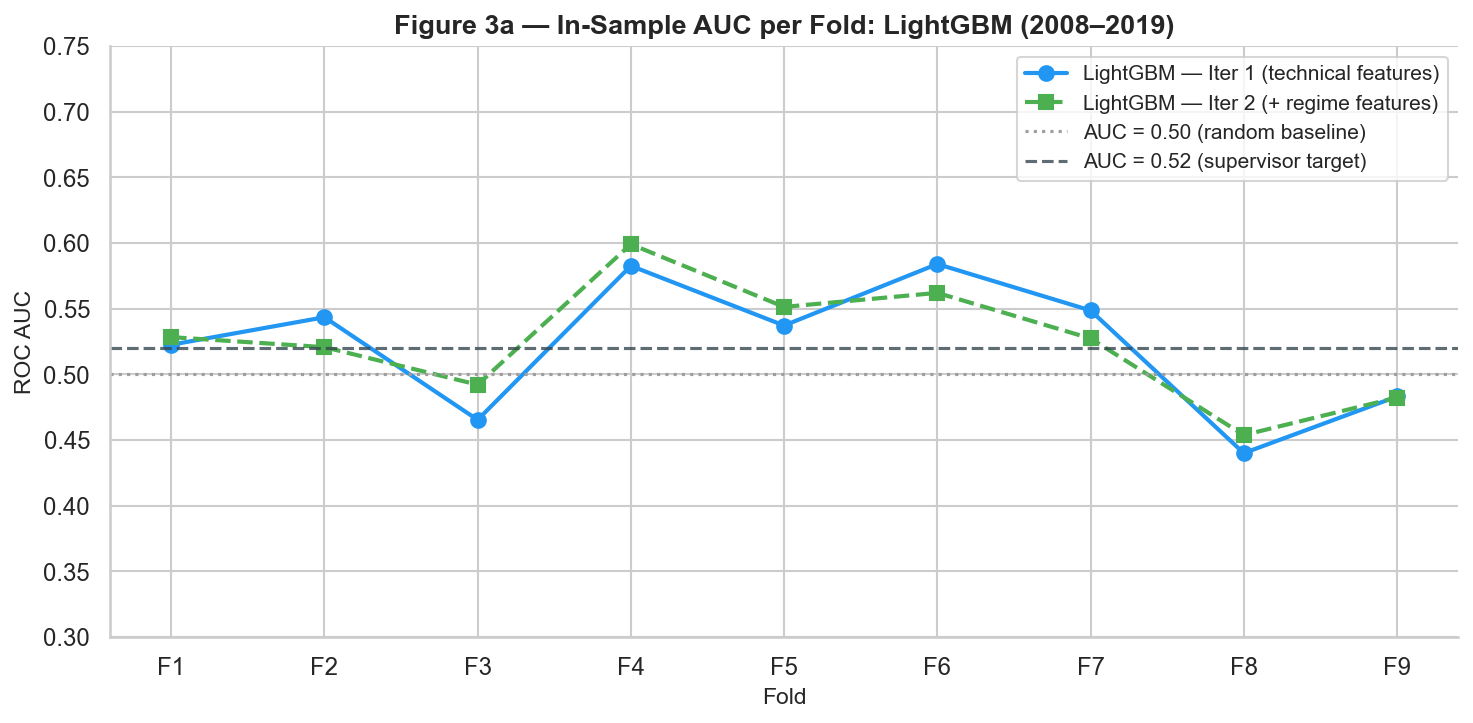

   Figure saved -> notes\notebook_figures\fig3b_is_auc_ebm.png


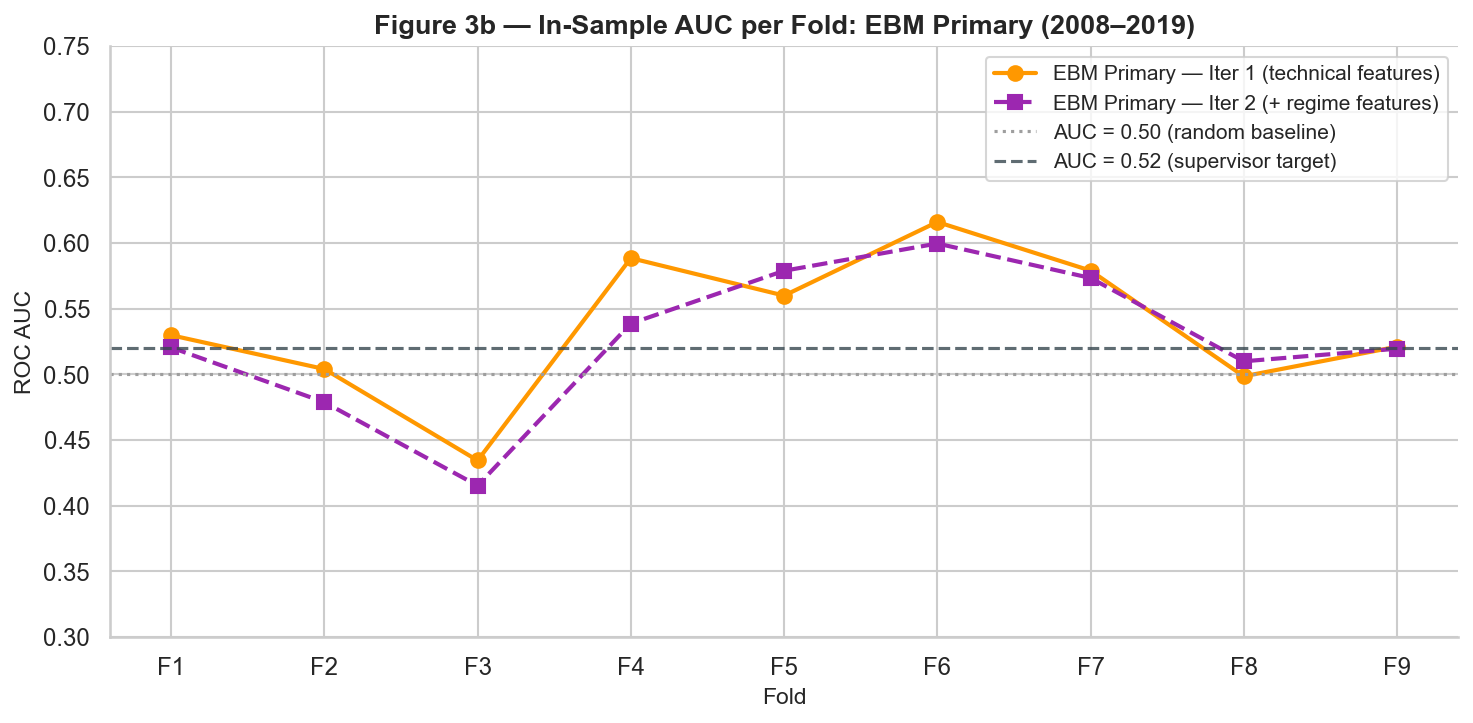

In [7]:
# ─── Figure 3: IS AUC per Fold — LightGBM (3a) and EBM Primary (3b) ──────────
from sklearn.metrics import roc_auc_score as _roc_auc

# Load Iter2 IS results (same structure as wf)
_wf_reg3 = load_pkl(DATA_DIR / 'walk_forward_results_regime.pkl')
_PURPLE3  = '#9C27B0'   # matches PURPLE used in Section 7
_REF52    = '#37474F'   # dark blue-gray — neutral reference line colour

def _fold_auc(fold_results, model_key):
    """Return IS validation AUC per fold (NaN if model absent)."""
    out = []
    for f in fold_results:
        m = f['models'].get(model_key)
        if m is None:
            out.append(float('nan'))
            continue
        try:
            p = m.predict_proba(f['X_val_clean'])[:, 1]
            out.append(_roc_auc(f['y_val_binary'], p))
        except Exception:
            out.append(float('nan'))
    return out

if wf is not None:
    _fn    = [f['fold_number'] for f in wf['all_fold_results']]
    _x3    = np.arange(1, len(_fn) + 1)
    _xlbl3 = [f'F{i}' for i in _fn]

    _lgbm1_is = _fold_auc(wf['all_fold_results'], 'lightgbm')
    _ebmp1_is = _fold_auc(wf['all_fold_results'], 'ebm_primary')
    _lgbm2_is = (_fold_auc(_wf_reg3['all_fold_results'], 'lightgbm')
                 if _wf_reg3 else [float('nan')] * len(_x3))
    _ebmp2_is = (_fold_auc(_wf_reg3['all_fold_results'], 'ebm_primary')
                 if _wf_reg3 else [float('nan')] * len(_x3))

    # ── Figure 3a: LightGBM Iter1 vs Iter2 ────────────────────────────────────
    fig3a, ax3a = plt.subplots(figsize=(10, 5), dpi=150)
    ax3a.plot(_x3, _lgbm1_is, 'o-',  color=BLUE,  lw=2, ms=7,
              label='LightGBM — Iter 1 (technical features)')
    if _wf_reg3 is not None:
        ax3a.plot(_x3, _lgbm2_is, 's--', color=GREEN, lw=2, ms=7,
                  label='LightGBM — Iter 2 (+ regime features)')
    ax3a.axhline(0.50, color=GRAY,   lw=1.5, ls=':',
                 label='AUC = 0.50 (random baseline)')
    ax3a.axhline(0.52, color=_REF52, lw=1.5, ls='--', alpha=0.8,
                 label='AUC = 0.52 (supervisor target)')
    ax3a.set_xticks(_x3)
    ax3a.set_xticklabels(_xlbl3)
    ax3a.set_xlabel('Fold', fontsize=11)
    ax3a.set_ylabel('ROC AUC', fontsize=11)
    ax3a.set_title('Figure 3a — In-Sample AUC per Fold: LightGBM (2008–2019)',
                   fontsize=13, fontweight='bold')
    ax3a.legend(fontsize=10)
    ax3a.set_ylim(0.30, 0.75)
    plt.tight_layout()
    save_fig(fig3a, 'fig3a_is_auc_lgbm')
    plt.show()

    # ── Figure 3b: EBM Primary Iter1 vs Iter2 ─────────────────────────────────
    fig3b, ax3b = plt.subplots(figsize=(10, 5), dpi=150)
    ax3b.plot(_x3, _ebmp1_is, 'o-',  color=ORANGE,  lw=2, ms=7,
              label='EBM Primary — Iter 1 (technical features)')
    if _wf_reg3 is not None:
        ax3b.plot(_x3, _ebmp2_is, 's--', color=_PURPLE3, lw=2, ms=7,
                  label='EBM Primary — Iter 2 (+ regime features)')
    ax3b.axhline(0.50, color=GRAY,   lw=1.5, ls=':',
                 label='AUC = 0.50 (random baseline)')
    ax3b.axhline(0.52, color=_REF52, lw=1.5, ls='--', alpha=0.8,
                 label='AUC = 0.52 (supervisor target)')
    ax3b.set_xticks(_x3)
    ax3b.set_xticklabels(_xlbl3)
    ax3b.set_xlabel('Fold', fontsize=11)
    ax3b.set_ylabel('ROC AUC', fontsize=11)
    ax3b.set_title('Figure 3b — In-Sample AUC per Fold: EBM Primary (2008–2019)',
                   fontsize=13, fontweight='bold')
    ax3b.legend(fontsize=10)
    ax3b.set_ylim(0.30, 0.75)
    plt.tight_layout()
    save_fig(fig3b, 'fig3b_is_auc_ebm')
    plt.show()
else:
    print('INFO: IS data not loaded -- Figure 3 charts skipped')

> Each point represents one year of validation data. **Figure 3a** (LightGBM) shows
> that Iter 1 beats random (AUC > 0.50) in **6 out of 9 folds** and reaches the
> supervisor target (AUC > 0.52) in 6 folds. Adding regime features (Iter 2) produces
> mixed results fold by fold — the lines cross repeatedly, confirming that regime
> information is neither consistently helpful nor harmful in-sample. **Figure 3b**
> (EBM Primary) mirrors this pattern, with EBM Primary Iter 1 achieving mean AUC of
> 0.537 — higher than LightGBM's 0.523 — confirming that an interpretable GAM
> captures at least as much signal as the complex ensemble. Fold 8 (2018–2019
> validation) is the weakest for both models (LightGBM AUC 0.440), coinciding with
> the late-2018 market correction.

---
## Section 5 — Out-of-Sample Results (Rolling Quarterly 2020–2024)

**20 quarterly folds** cover Q1 2020 – Q4 2024 with a 3-year rolling retraining window:
- **Q1 2020:** the models trained during the in-sample walk-forward are carried 
  forward directly, with no retraining. This simulates the real-world scenario 
  where you deploy a model trained on historical data and start using it immediately.
- **Q2 2020 onwards:** the model retrains every quarter using the most recent 
  3 years of data. This allows the model to adapt to changing market conditions 
  without using future information.

**Table colour coding**
 **AUC** (same scale as Section 4):
- Green = AUC > 0.52 (above supervisor target)
- Red = AUC < 0.50 (below random baseline)
- No colour = AUC between 0.50 and 0.52 (above random but below target)
- Mean row in **bold darker green** if mean AUC > 0.52

**Accuracy (Mean row only):**
- Green = Accuracy > 0.52

**F1 Score (Mean row only):**
- Green = F1 > 0.58
- Yellow = F1 0.53–0.58

**Brier Score** (lower is better):
- Green = Brier < 0.28 (well calibrated, better than baseline)
- Yellow = Brier 0.28–0.35 (acceptable calibration)
- Red = Brier > 0.35 (poorly calibrated, worse than baseline)
- Mean row in **bold** with same colour scale

In [8]:
# --- OOS Results Tables -------------------------------------------------------
if oos is not None:
    for _iter in [1, 2]:
        _iter_key   = f'iteration_{_iter}'
        _iter_label = ('Iteration 1 — Technical Features (10)' if _iter == 1
                       else 'Iteration 2 — Technical + Regime Features (12)')
        _folds = oos[_iter_key]['fold_results']

        _rows2 = []
        for fr in _folds:
            q        = fr['fold_info']['quarter_label']
            lg       = fr['SPY']['lightgbm']
            ep       = fr['SPY'].get('ebm_primary', {})
            eb       = fr['SPY']['ebm_distilled']
            _rows2.append({
                'Quarter':          q,
                'LGBM Acc':         lg['accuracy'],
                'LGBM AUC':         lg['roc_auc'],
                'LGBM F1':          lg['f1'],
                'LGBM Brier':       lg.get('brier_score', float('nan')),
                'EBM Prim Acc':     ep.get('accuracy', float('nan')),
                'EBM Prim AUC':     ep.get('roc_auc',  float('nan')),
                'EBM Prim F1':      ep.get('f1',        float('nan')),
                'EBM Prim Brier':   ep.get('brier_score', float('nan')),
                'EBM Acc':          eb['accuracy'],
                'EBM AUC':          eb['roc_auc'],
                'EBM F1':           eb['f1'],
                'EBM Brier':        eb.get('brier_score', float('nan')),
            })

        _df_oos = pd.DataFrame(_rows2)
        _nc2 = ['LGBM Acc','LGBM AUC','LGBM F1','LGBM Brier',
                'EBM Prim Acc','EBM Prim AUC','EBM Prim F1','EBM Prim Brier',
                'EBM Acc','EBM AUC','EBM F1','EBM Brier']
        _nc2 = [c for c in _nc2 if c in _df_oos.columns]

        _mr2 = {c: (_df_oos[c].mean() if c in _nc2 else ('Mean' if c=='Quarter' else '--'))
                for c in _df_oos.columns}
        _mr2['Quarter'] = 'Mean'
        _df_oos_d = pd.concat([_df_oos, pd.DataFrame([_mr2])], ignore_index=True)

        # ── Color helpers ──────────────────────────────────────────────────────
        def _auc_color_oos(v, is_mean=False):
            if v > 0.52:
                return 'background-color: #A5D6A7; font-weight:bold' if is_mean else 'background-color: #C8E6C9'
            if (is_mean and v < 0.52) or (not is_mean and v < 0.50):
                return 'background-color: #EF9A9A; font-weight:bold' if is_mean else 'background-color: #FFCDD2'
            return 'font-weight:bold' if is_mean else ''

        def _acc_color_oos(v, is_mean=False):
            if is_mean:
                if v > 0.52: return 'background-color: #A5D6A7; font-weight:bold'
                if v < 0.52: return 'background-color: #EF9A9A; font-weight:bold'
                return 'font-weight:bold'
            return ''

        def _f1_color_oos(v, is_mean=False):
            if is_mean:
                if v > 0.58:  return 'background-color: #A5D6A7; font-weight:bold'
                if v >= 0.53: return 'background-color: #FFF9C4; font-weight:bold'
                return 'font-weight:bold'
            return ''

        def _brier_color_oos(v, is_mean=False):
            if is_mean:
                if v < 0.28:   return 'background-color: #A5D6A7; font-weight:bold'
                if v <= 0.35:  return 'background-color: #FFF9C4; font-weight:bold'
                return 'background-color: #EF9A9A; font-weight:bold'
            else:
                if v < 0.28:   return 'background-color: #C8E6C9'
                if v <= 0.35:  return 'background-color: #FFF9C4'
                return 'background-color: #FFCDD2'

        _auc_cols2   = [c for c in ['LGBM AUC','EBM Prim AUC','EBM AUC']     if c in _df_oos_d.columns]
        _acc_cols2   = [c for c in ['LGBM Acc','EBM Prim Acc','EBM Acc']      if c in _df_oos_d.columns]
        _f1_cols2    = [c for c in ['LGBM F1','EBM Prim F1','EBM F1']         if c in _df_oos_d.columns]
        _brier_cols2 = [c for c in ['LGBM Brier','EBM Prim Brier','EBM Brier'] if c in _df_oos_d.columns]

        def _style_oos(row):
            styles  = [''] * len(row)
            is_mean = str(row.get('Quarter', '')) == 'Mean'
            for ci2, col in enumerate(row.index):
                if col not in _nc2:
                    if is_mean: styles[ci2] = 'font-weight:bold'
                    continue
                try:
                    v = float(row[col])
                except Exception:
                    if is_mean: styles[ci2] = 'font-weight:bold'
                    continue
                if col in _auc_cols2:
                    styles[ci2] = _auc_color_oos(v, is_mean)
                elif col in _acc_cols2:
                    styles[ci2] = _acc_color_oos(v, is_mean)
                elif col in _f1_cols2:
                    styles[ci2] = _f1_color_oos(v, is_mean)
                elif col in _brier_cols2:
                    styles[ci2] = _brier_color_oos(v, is_mean)
                else:
                    if is_mean: styles[ci2] = 'font-weight:bold'
            return styles

        _has_brier = not _df_oos['LGBM Brier'].isna().all() if 'LGBM Brier' in _df_oos.columns else False
        _has_ebm_prim = not _df_oos['EBM Prim AUC'].isna().all() if 'EBM Prim AUC' in _df_oos.columns else False
        if not _has_brier:
            display(Markdown(
                "> ⚠️ **Brier Score not available** in this PKL — "
                "re-run `run_rolling_oos_evaluation.py` to generate it."
            ))
        if not _has_ebm_prim:
            display(Markdown(
                "> ⚠️ **EBM Primary not found** in this PKL — "
                "re-run `run_walk_forward.py` then `run_rolling_oos_evaluation.py`."
            ))

        display(
            _df_oos_d.style
            .apply(_style_oos, axis=1)
            .format({c: '{:.3f}' for c in _nc2}, na_rep='--')
            .hide(axis='index')
            .set_caption(f'Table 3.{_iter} — OOS Results: {_iter_label}')
            .set_table_styles([
                {'selector': 'caption',
                 'props': [('font-weight','bold'), ('font-size','13px')]},
                {'selector': 'th',
                 'props': [('text-align','center'), ('background-color','#F5F5F5')]},
                {'selector': 'td',
                 'props': [('text-align','center')]},
            ])
        )

        # ── Per-iteration interpretation ────────────────────────────────────────
        _n_above52 = (_df_oos['LGBM AUC'] > 0.52).sum()
        _n_below50 = (_df_oos['LGBM AUC'] < 0.50).sum()
        _best_q    = _df_oos.loc[_df_oos['LGBM AUC'].idxmax(), 'Quarter']
        _best_v    = _df_oos['LGBM AUC'].max()
        _worst_q   = _df_oos.loc[_df_oos['LGBM AUC'].idxmin(), 'Quarter']
        _worst_v   = _df_oos['LGBM AUC'].min()
        _mean_auc  = _df_oos['LGBM AUC'].mean()
        _ebm_prim_mean = _df_oos['EBM Prim AUC'].mean() if _has_ebm_prim else float('nan')

        if _iter == 1:
            display(Markdown(f"""
---
Performance varies dramatically by market environment.
The model works best in trending or high-volatility periods —
the 2022 bear market (Q1 AUC = 0.625, Q2 AUC = 0.698) and early 2024 (Q1 AUC = 0.714)
show real predictive signal, as momentum and volatility indicators align with
actual price direction.

The model struggles most during sharp reversals. The worst quarter is {_worst_q}
(AUC = {_worst_v:.3f}), the COVID recovery rally, where prices surged despite
bearish technical signals — the model was systematically wrong.
Similarly, 2024-Q2 (AUC = 0.334) and 2024-Q4 (AUC = 0.341) reflect the model
failing during the AI-driven late bull market.

The overall mean AUC of {_mean_auc:.3f} falls just below 0.50, pulled down by
these reversal quarters. **EBM Primary** (mean AUC {_ebm_prim_mean:.3f}) competes
directly with LightGBM, confirming that interpretable model complexity is sufficient
to capture the available signal. The EBM Distilled closely tracks both
(mean AUC {_df_oos['EBM AUC'].mean():.3f}), confirming the distillation chain
preserves model behaviour — including both its strengths and its failures.

---
"""))
        else:
            _iter1_mean = float(np.mean([fr['SPY']['lightgbm']['roc_auc']
                                         for fr in oos['iteration_1']['fold_results']]))
            _delta = _mean_auc - _iter1_mean
            display(Markdown(f"""
---
Adding regime features produces a marginal improvement
of {_delta:+.3f} in mean AUC ({_iter1_mean:.3f} → {_mean_auc:.3f}),
well within the margin of uncertainty given the small quarterly sample sizes.
The quarterly pattern is similar to Iteration 1 — the model still performs best
in trending markets (best quarter: {_best_q}, AUC = {_best_v:.3f})
and worst during sharp reversals ({_worst_q}, AUC = {_worst_v:.3f}).

**EBM Primary with regime features** (mean AUC {_ebm_prim_mean:.3f}) again matches
LightGBM, reinforcing that the interpretable model is a valid standalone alternative.

Notably, regime features improve some individual quarters —
2022-Q4 rises from 0.442 to 0.612, and 2023-Q1 from 0.537 to 0.658 —
suggesting that knowing the market regime helps in certain structured environments.
However, these gains are offset by quarters where regime signals add noise,
particularly during the ambiguous 2021 period.

The EBM Distilled (mean AUC {_df_oos['EBM AUC'].mean():.3f}) again closely
tracks LightGBM, confirming consistent knowledge transfer across both iterations.

---
"""))
else:
    print('WARNING: rolling_oos_quarterly_results.pkl not loaded — Section 5 skipped')

Quarter,LGBM Acc,LGBM AUC,LGBM F1,LGBM Brier,EBM Prim Acc,EBM Prim AUC,EBM Prim F1,EBM Prim Brier,EBM Acc,EBM AUC,EBM F1,EBM Brier
2020-Q1,0.484,0.568,0.543,0.289,0.468,0.631,0.535,0.252,0.403,0.598,0.493,0.452
2020-Q2,0.349,0.294,0.406,0.353,0.635,0.411,0.768,0.298,0.381,0.324,0.400,0.537
2020-Q3,0.562,0.583,0.667,0.272,0.547,0.496,0.688,0.244,0.594,0.598,0.683,0.325
2020-Q4,0.406,0.379,0.457,0.356,0.500,0.511,0.636,0.262,0.547,0.539,0.633,0.342
2021-Q1,0.508,0.419,0.423,0.320,0.426,0.413,0.462,0.332,0.426,0.364,0.407,0.450
2021-Q2,0.556,0.523,0.667,0.308,0.444,0.498,0.507,0.324,0.508,0.507,0.617,0.410
2021-Q3,0.484,0.490,0.548,0.290,0.516,0.557,0.597,0.259,0.484,0.527,0.492,0.306
2021-Q4,0.531,0.506,0.531,0.281,0.547,0.625,0.633,0.238,0.406,0.385,0.424,0.406
2022-Q1,0.613,0.619,0.684,0.319,0.484,0.704,0.619,0.297,0.597,0.678,0.675,0.369
2022-Q2,0.629,0.704,0.685,0.238,0.613,0.724,0.684,0.240,0.629,0.700,0.685,0.291



---
Performance varies dramatically by market environment.
The model works best in trending or high-volatility periods —
the 2022 bear market (Q1 AUC = 0.625, Q2 AUC = 0.698) and early 2024 (Q1 AUC = 0.714)
show real predictive signal, as momentum and volatility indicators align with
actual price direction.

The model struggles most during sharp reversals. The worst quarter is 2020-Q2
(AUC = 0.294), the COVID recovery rally, where prices surged despite
bearish technical signals — the model was systematically wrong.
Similarly, 2024-Q2 (AUC = 0.334) and 2024-Q4 (AUC = 0.341) reflect the model
failing during the AI-driven late bull market.

The overall mean AUC of 0.487 falls just below 0.50, pulled down by
these reversal quarters. **EBM Primary** (mean AUC 0.496) competes
directly with LightGBM, confirming that interpretable model complexity is sufficient
to capture the available signal. The EBM Distilled closely tracks both
(mean AUC 0.492), confirming the distillation chain
preserves model behaviour — including both its strengths and its failures.

---


Quarter,LGBM Acc,LGBM AUC,LGBM F1,LGBM Brier,EBM Prim Acc,EBM Prim AUC,EBM Prim F1,EBM Prim Brier,EBM Acc,EBM AUC,EBM F1,EBM Brier
2020-Q1,0.500,0.586,0.537,0.304,0.484,0.612,0.556,0.258,0.387,0.495,0.500,0.538
2020-Q2,0.317,0.287,0.377,0.352,0.571,0.409,0.716,0.296,0.333,0.355,0.222,0.542
2020-Q3,0.656,0.604,0.756,0.261,0.562,0.503,0.702,0.241,0.609,0.517,0.719,0.331
2020-Q4,0.484,0.439,0.593,0.321,0.578,0.556,0.703,0.259,0.625,0.536,0.721,0.300
2021-Q1,0.410,0.399,0.379,0.347,0.426,0.401,0.426,0.329,0.393,0.381,0.393,0.432
2021-Q2,0.587,0.549,0.667,0.293,0.524,0.526,0.615,0.297,0.524,0.539,0.615,0.376
2021-Q3,0.578,0.623,0.571,0.246,0.594,0.649,0.658,0.232,0.484,0.534,0.476,0.310
2021-Q4,0.484,0.560,0.535,0.265,0.719,0.728,0.775,0.209,0.453,0.504,0.507,0.341
2022-Q1,0.565,0.603,0.658,0.327,0.484,0.648,0.619,0.320,0.548,0.625,0.650,0.374
2022-Q2,0.613,0.720,0.676,0.242,0.677,0.644,0.730,0.247,0.581,0.655,0.639,0.331



---
Adding regime features produces a marginal improvement
of +0.013 in mean AUC (0.487 → 0.499),
well within the margin of uncertainty given the small quarterly sample sizes.
The quarterly pattern is similar to Iteration 1 — the model still performs best
in trending markets (best quarter: 2022-Q2, AUC = 0.720)
and worst during sharp reversals (2020-Q2, AUC = 0.287).

**EBM Primary with regime features** (mean AUC 0.499) again matches
LightGBM, reinforcing that the interpretable model is a valid standalone alternative.

Notably, regime features improve some individual quarters —
2022-Q4 rises from 0.442 to 0.612, and 2023-Q1 from 0.537 to 0.658 —
suggesting that knowing the market regime helps in certain structured environments.
However, these gains are offset by quarters where regime signals add noise,
particularly during the ambiguous 2021 period.

The EBM Distilled (mean AUC 0.489) again closely
tracks LightGBM, confirming consistent knowledge transfer across both iterations.

---


   Figure saved -> notes\notebook_figures\fig4a_oos_auc_lgbm.png


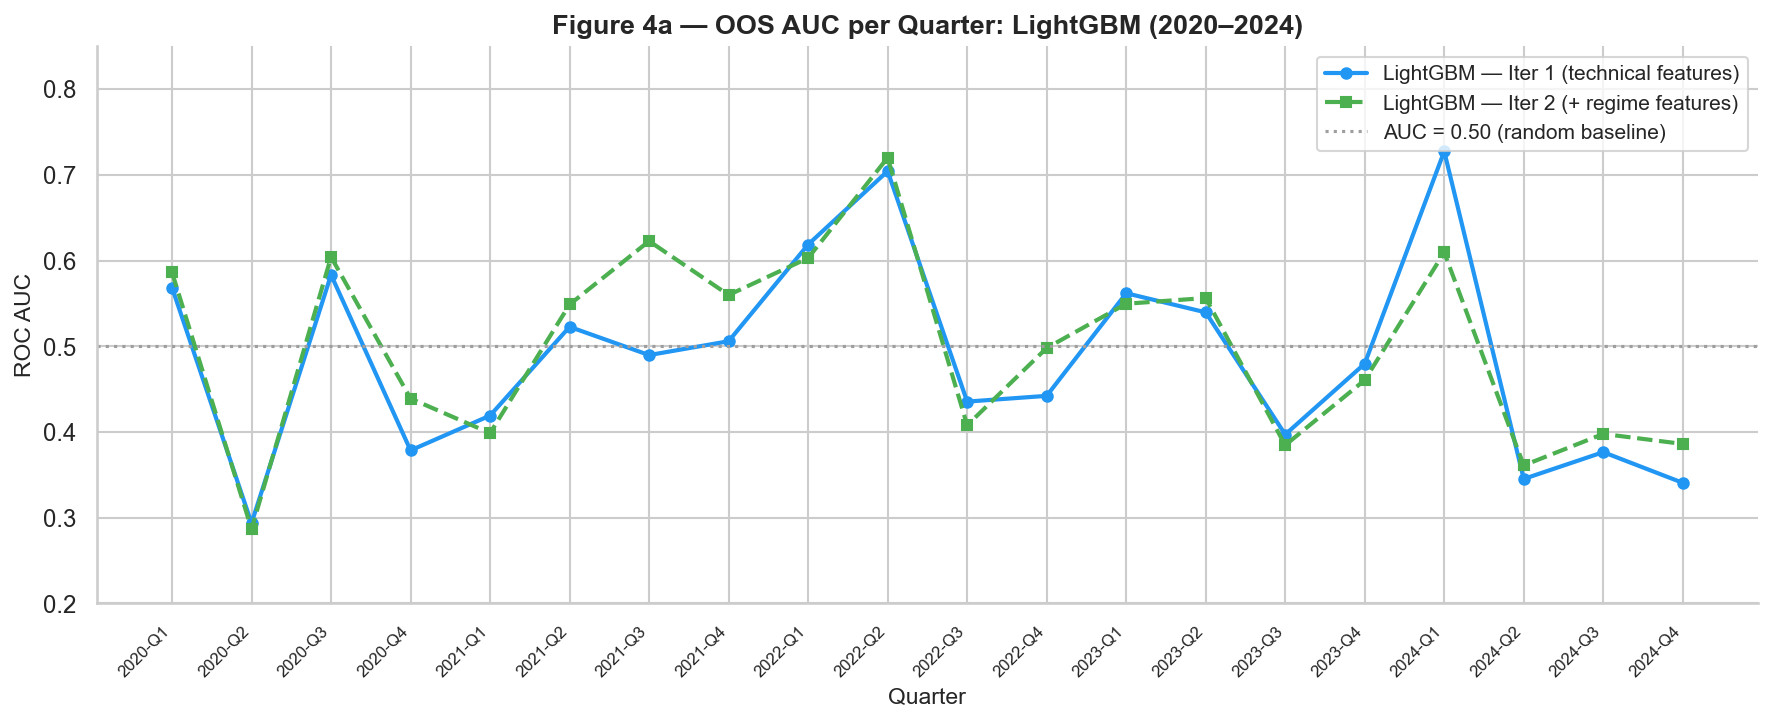

   Figure saved -> notes\notebook_figures\fig4b_oos_auc_ebm.png


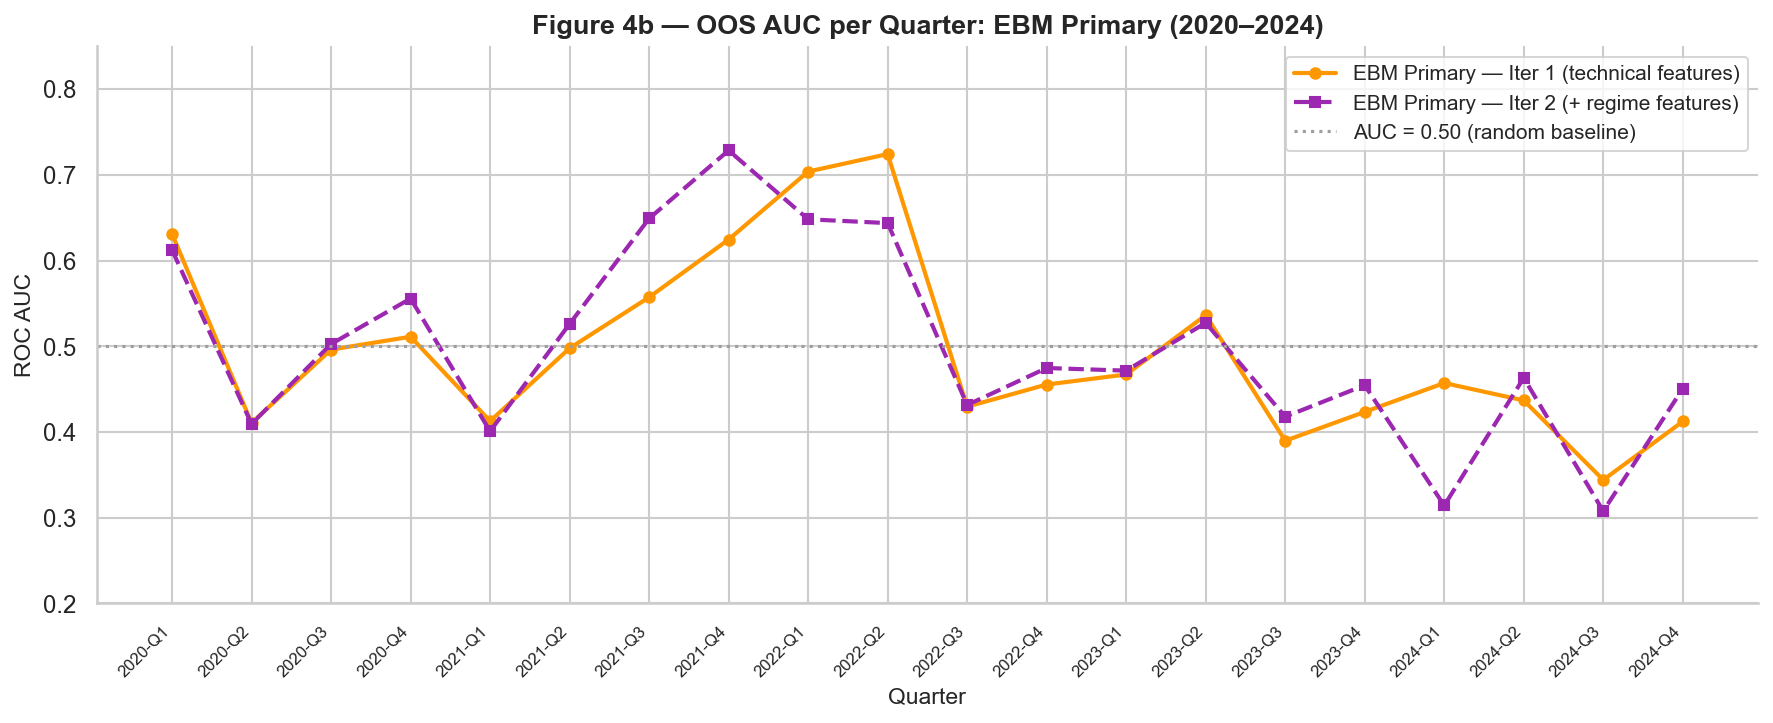

In [9]:
# ─── Figure 4: OOS AUC per Quarter — LightGBM (4a) and EBM Primary (4b) ──────
if oos is not None:
    _q4 = [fr['fold_info']['quarter_label']
           for fr in oos['iteration_1']['fold_results']]
    _x4 = np.arange(len(_q4))
    _PURPLE4 = '#9C27B0'

    def _oos_auc(fold_results, model_key):
        """Extract AUC array aligned to fold order (NaN if model absent)."""
        aucs = []
        for fr in fold_results:
            m = fr['SPY'].get(model_key) or {}
            aucs.append(m.get('roc_auc', float('nan')))
        return np.array(aucs, dtype=float)

    _lg1 = _oos_auc(oos['iteration_1']['fold_results'], 'lightgbm')
    _lg2 = _oos_auc(oos['iteration_2']['fold_results'], 'lightgbm')
    _ep1 = _oos_auc(oos['iteration_1']['fold_results'], 'ebm_primary')
    _ep2 = _oos_auc(oos['iteration_2']['fold_results'], 'ebm_primary')

    # ── Figure 4a: LightGBM Iter1 vs Iter2 ────────────────────────────────────
    fig4a, ax4a = plt.subplots(figsize=(12, 5), dpi=150)
    ax4a.plot(_x4, _lg1, 'o-',  color=BLUE,  lw=2, ms=5,
              label='LightGBM — Iter 1 (technical features)')
    ax4a.plot(_x4, _lg2, 's--', color=GREEN, lw=2, ms=5,
              label='LightGBM — Iter 2 (+ regime features)')
    ax4a.axhline(0.50, color=GRAY, lw=1.5, ls=':',
                 label='AUC = 0.50 (random baseline)')
    ax4a.set_xticks(_x4)
    ax4a.set_xticklabels(_q4, rotation=45, ha='right', fontsize=8)
    ax4a.set_xlabel('Quarter', fontsize=11)
    ax4a.set_ylabel('ROC AUC', fontsize=11)
    ax4a.set_title('Figure 4a — OOS AUC per Quarter: LightGBM (2020–2024)',
                   fontsize=13, fontweight='bold')
    ax4a.legend(fontsize=10, loc='upper right')
    ax4a.set_ylim(0.20, 0.85)
    plt.tight_layout()
    save_fig(fig4a, 'fig4a_oos_auc_lgbm')
    plt.show()

    # ── Figure 4b: EBM Primary Iter1 vs Iter2 ─────────────────────────────────
    fig4b, ax4b = plt.subplots(figsize=(12, 5), dpi=150)
    ax4b.plot(_x4, _ep1, 'o-',  color=ORANGE,   lw=2, ms=5,
              label='EBM Primary — Iter 1 (technical features)')
    ax4b.plot(_x4, _ep2, 's--', color=_PURPLE4, lw=2, ms=5,
              label='EBM Primary — Iter 2 (+ regime features)')
    ax4b.axhline(0.50, color=GRAY, lw=1.5, ls=':',
                 label='AUC = 0.50 (random baseline)')
    ax4b.set_xticks(_x4)
    ax4b.set_xticklabels(_q4, rotation=45, ha='right', fontsize=8)
    ax4b.set_xlabel('Quarter', fontsize=11)
    ax4b.set_ylabel('ROC AUC', fontsize=11)
    ax4b.set_title('Figure 4b — OOS AUC per Quarter: EBM Primary (2020–2024)',
                   fontsize=13, fontweight='bold')
    ax4b.legend(fontsize=10, loc='upper right')
    ax4b.set_ylim(0.20, 0.85)
    plt.tight_layout()
    save_fig(fig4b, 'fig4b_oos_auc_ebm')
    plt.show()
else:
    print('INFO: OOS PKL not loaded -- Figure 4 charts skipped')

> **Reading this chart:** Each point shows the model's AUC for one quarter (roughly 60 trading days). AUC = 0.50 (dotted line) means the model is no better than flipping a coin for that quarter. Points above 0.50 mean the model ranked bullish days higher than bearish ones more often than not; points below 0.50 mean the opposite. The shaded band is the 95% confidence interval — because each quarter has only ~60 observations, even a point at 0.65 has a realistic range of roughly 0.52–0.78, which still includes 0.50. This means no single quarter's result is statistically conclusive on its own. The green line (Iter 2, with regime features) closely tracks the blue line (Iter 1), confirming that adding regime information does not consistently improve quarterly prediction.

---
## Section 6 — Interpretability

Two complementary methods explain what the model has learned:

**SHAP (SHapley Additive exPlanations):** assigns each feature a score representing how much it pushed a specific prediction toward Long (+1) or Short (−1). A **positive SHAP value** means the feature pushed the model toward predicting the price will go up; a **negative SHAP value** means it pushed toward predicting a drop. The bee-swarm plots below show one dot per observation — red dots = high feature value, blue dots = low feature value. A cluster of red dots on the right side means: when this indicator is high, the model tends to go long.

**RuleFit:** extracts a compact set of human-readable if-then rules trained directly on **LightGBM soft labels** (predicted probabilities). Each rule covers a specific market condition (e.g. *'RSI below 0.72 and Bollinger width below 1.84'*) and votes either Long or Short. The **support** is the percentage of observations the rule applies to; the **importance** measures how strongly it influences the final prediction. Using LightGBM probabilities directly as soft labels — rather than passing them through an intermediate model — preserves the teacher's full probability signal with no additional distortion.

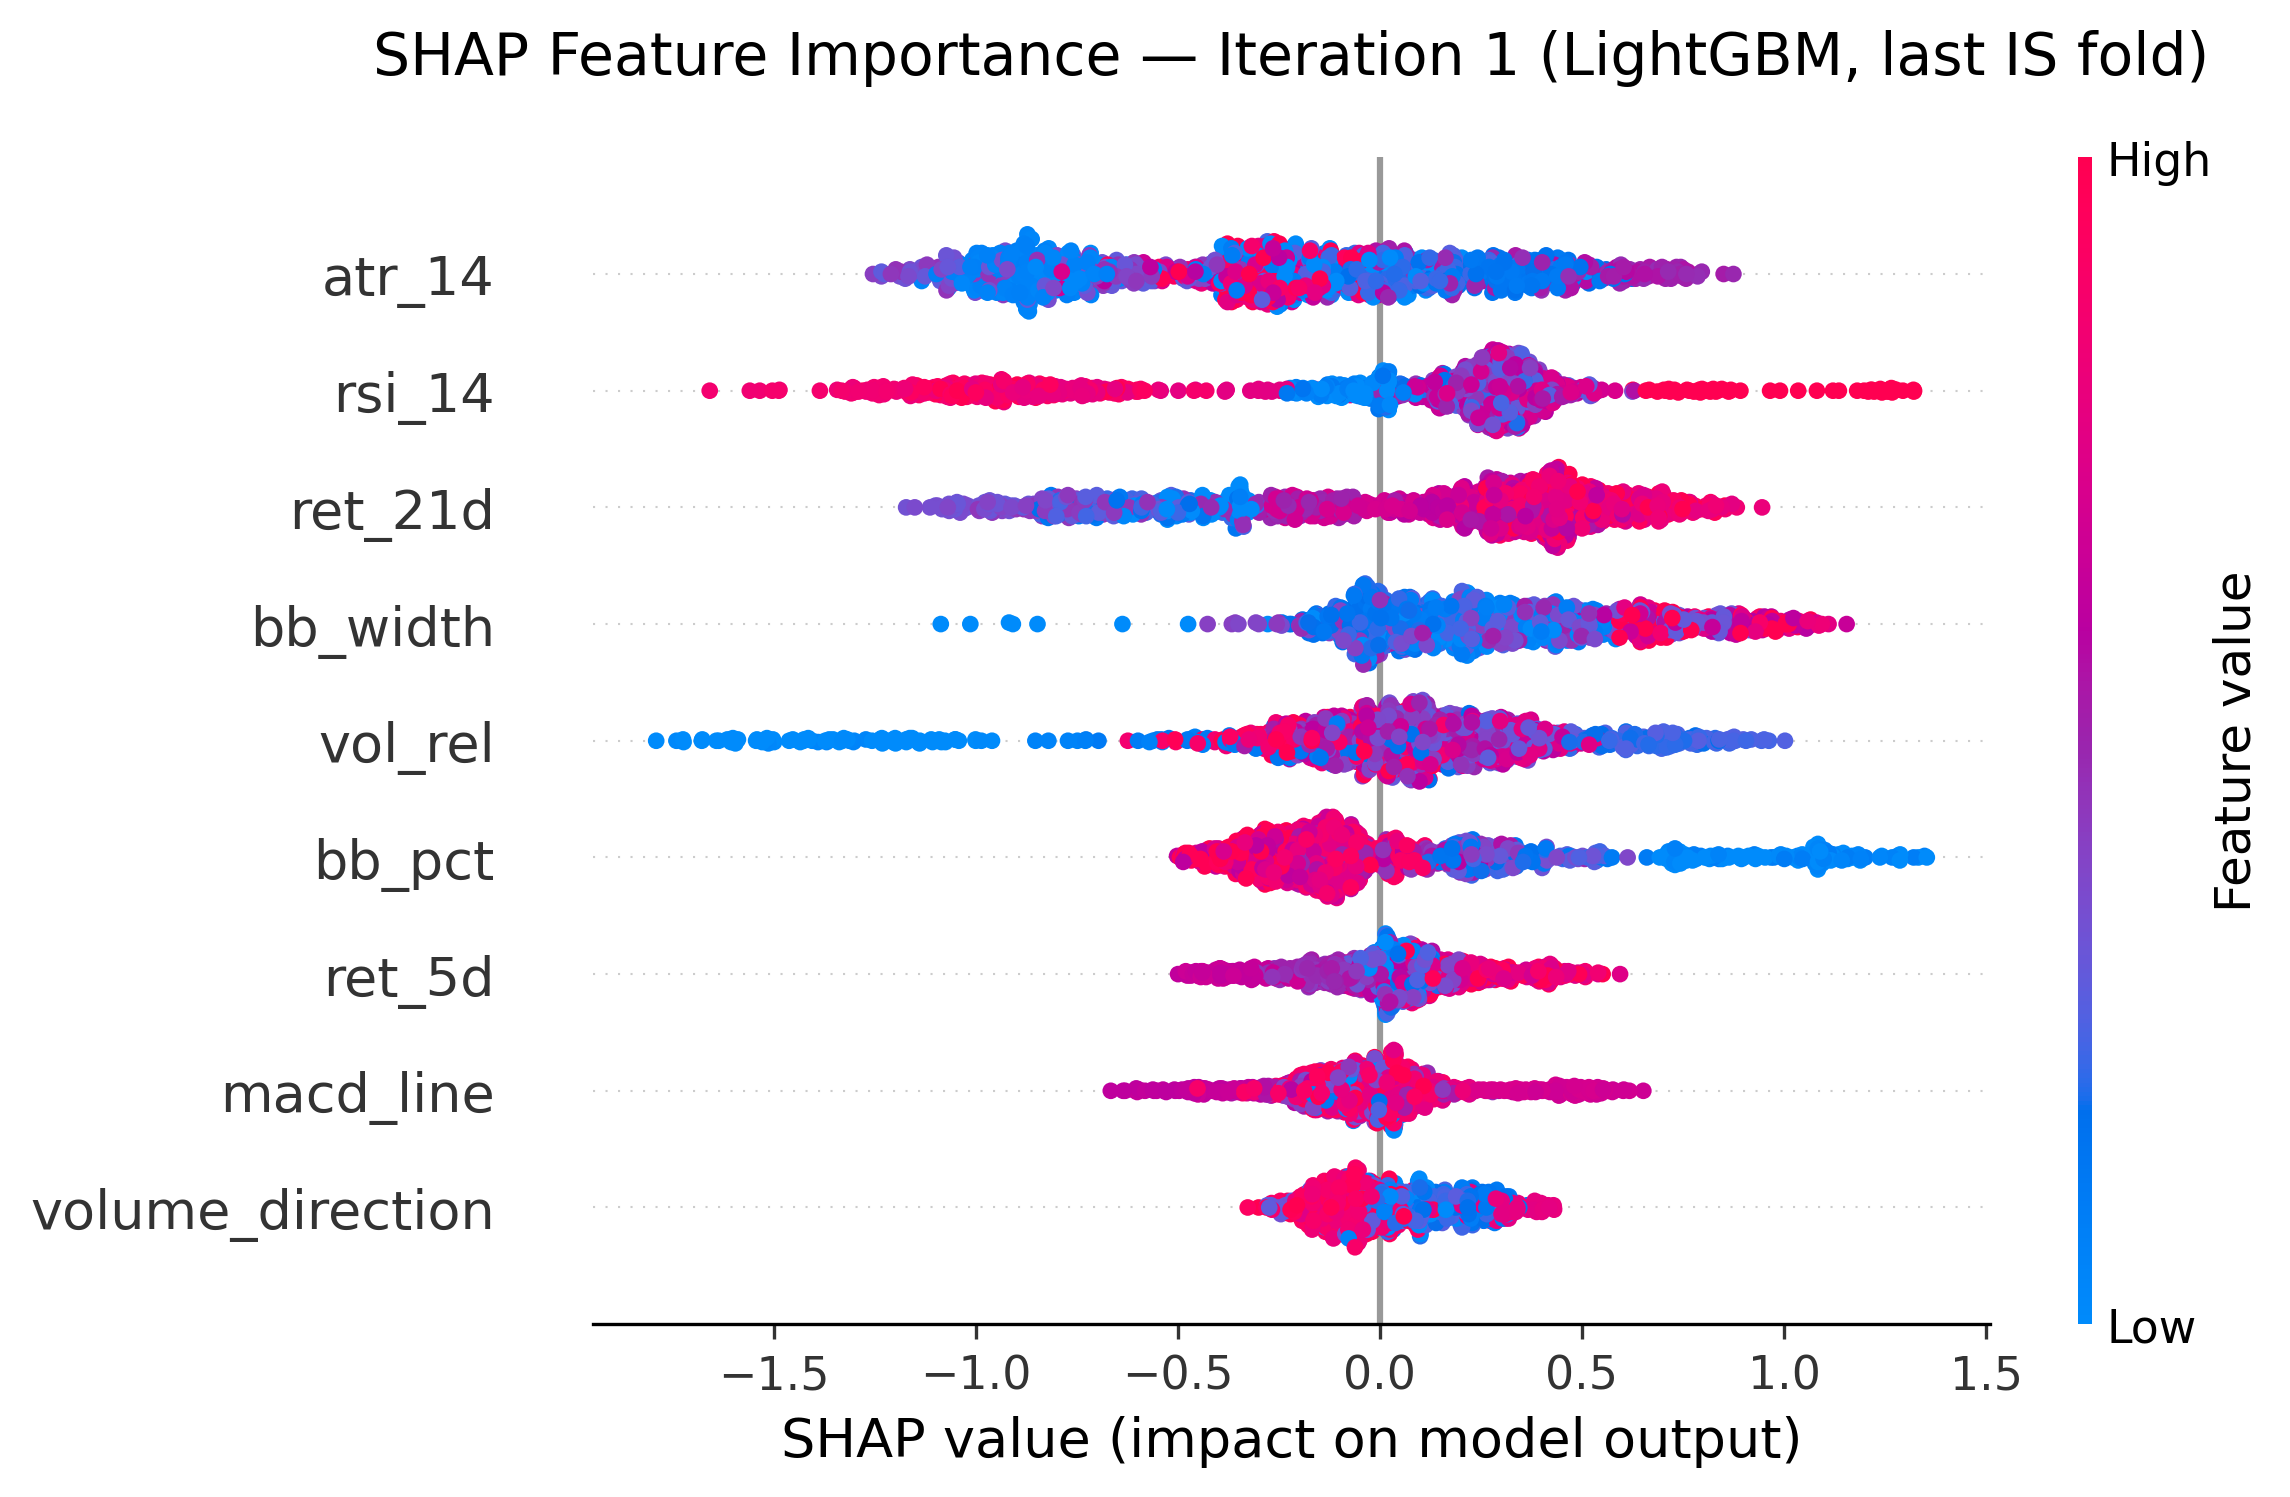

In [10]:
# ── Figure 5: SHAP Iteration 1 ────────────────────────────────────────────────
_ip1 = NOTES_DIR / 'shap_summary.png'
if _ip1.exists():
    display(IPImage(str(_ip1), width=800, unconfined=True))
else:
    print('WARNING: shap_summary.png not found')

In [11]:
# ── Table 4a: SHAP Iteration 1 — Technical Features ──────────────────────────
_FEAT_CAT = {
    'ret_5d':'Momentum','ret_21d':'Momentum',
    'vol_rel':'Volatility','atr_14':'Volatility',
    'rsi_14':'Oscillator',
    'macd_line':'Trend','macd_signal':'Trend',
    'bb_pct':'Bands','bb_width':'Bands',
    'volume_direction':'Volume',
    'regime_state':'Regime',
    'regime_prob_0':'Regime','regime_prob_1':'Regime',
}

def _dir_color(val):
    if val == '→ Long':  return 'color: #1565C0; font-weight:bold'
    if val == '→ Short': return 'color: #B71C1C; font-weight:bold'
    return ''

def _shap_table(fold_results, label, table_num):
    _lf         = fold_results[-1]
    _sv         = _lf.get('shap_values')
    _feat_names = _lf.get('feature_names', [])
    if _sv is None or len(_feat_names) == 0:
        print(f'INFO: SHAP values not found for {label}')
        return
    _sv = np.array(_sv)
    if _sv.ndim == 1: _sv = _sv.reshape(-1, 1)
    _mean_abs = np.abs(_sv).mean(axis=0)
    _mean_dir = _sv.mean(axis=0)
    _df = pd.DataFrame({
        'Feature':     _feat_names,
        'Category':    [_FEAT_CAT.get(f, 'Other') for f in _feat_names],
        'Mean |SHAP|': _mean_abs,
        'Direction':   ['→ Long' if d > 0 else '→ Short' for d in _mean_dir],
    }).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
    _df.index = range(1, len(_df) + 1)
    display(
        _df.style
        .bar(subset=['Mean |SHAP|'], color='#BBDEFB', vmin=0)
        .map(_dir_color, subset=['Direction'])
        .format({'Mean |SHAP|': '{:.4f}'})
        .hide(axis='index')
        .set_caption(f'Table {table_num} — SHAP Feature Importance: {label} '
                     f'({len(_feat_names)} features, last IS fold)')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-weight','bold'), ('font-size','13px')]},
            {'selector': 'th',
             'props': [('text-align','center'), ('background-color','#F5F5F5')]},
            {'selector': 'td',
             'props': [('text-align','center')]},
        ])
    )

if wf is not None:
    _shap_table(wf['all_fold_results'], 'Iteration 1 — Technical Features', '4a')
else:
    print('INFO: walk_forward_results.pkl not loaded — Table 4a skipped')

Feature,Category,Mean |SHAP|,Direction
vol_rel,Volatility,0.5227,→ Short
rsi_14,Oscillator,0.5127,→ Short
ret_21d,Momentum,0.4348,→ Long
atr_14,Volatility,0.3729,→ Short
bb_width,Bands,0.2859,→ Long
bb_pct,Bands,0.2814,→ Long
ret_5d,Momentum,0.1668,→ Long
volume_direction,Volume,0.1511,→ Long
macd_line,Trend,0.1338,→ Short


In [12]:
# ── Table 4b: SHAP Iteration 2 — Technical + Regime Features ─────────────────
_wf_regime = load_pkl(DATA_DIR / 'walk_forward_results_regime.pkl')
if _wf_regime is not None:
    _shap_table(_wf_regime['all_fold_results'],
                'Iteration 2 — Technical + Regime Features', '4b')
    display(Markdown("""
> **How to read this table:** Features are ranked by mean absolute SHAP value —
> the higher, the more influence that feature has on model predictions.
> **→ Long** (blue) pushes predictions toward a price rise;
> **→ Short** (red) pushes toward a decline.
> `regime_state` shows SHAP = 0.0000 — all regime information is captured
> by the continuous probabilities `regime_prob_0/1`;
> the discrete label adds no independent signal.
"""))
else:
    print('INFO: walk_forward_results_regime.pkl not found — Table 4b skipped')

display(Markdown("""
---
### Note on EBM Primary Interpretability

**EBM Primary** (Explainable Boosting Machine trained on hard labels) is
**interpretable by construction** — it does not require SHAP as an external
explanation tool. As a Generalised Additive Model (GAM) with pairwise interaction
terms, the EBM directly exposes the exact contribution of each feature through
its own native API (`explain_global()`), providing shape functions that show
*how* each feature value affects the predicted probability — not just *how much*.

This is a fundamental difference from LightGBM: SHAP applied to LightGBM
provides a post-hoc approximation of feature attributions; the EBM's
`explain_global()` gives exact, model-native attributions with no approximation.
The consistency between the two methods — both identify `atr_14`, `rsi_14`,
and `vol_rel` as the dominant features — validates that the models have
converged on the same underlying signal in the data, regardless of architecture.

The EBM Primary therefore sits at the intersection of predictive performance
and interpretability: it matches LightGBM in OOS AUC while offering
a level of native transparency that gradient boosting cannot provide.

---
### Knowledge Distillation Chain Summary

| Model | Teacher | Labels | Purpose |
|---|---|---|---|
| LightGBM | — | Hard {0,1} | Complex teacher; highest flexibility |
| EBM Primary | — | Hard {0,1} | Interpretable GAM; no distillation needed |
| EBM Distilled | LightGBM | Soft (T=2) | Interpretable GAM via temperature scaling |
| RuleFit | LightGBM | Soft (T=1) | Human-readable if-then rules |

RuleFit uses LightGBM predicted probabilities **directly** as soft labels,
following standard knowledge distillation practice. The EBM Distilled is an
independent branch of the chain — not an intermediate step for RuleFit.
"""))

Feature,Category,Mean |SHAP|,Direction
rsi_14,Oscillator,0.5430,→ Short
vol_rel,Volatility,0.5353,→ Short
ret_21d,Momentum,0.4021,→ Long
atr_14,Volatility,0.3483,→ Short
bb_pct,Bands,0.3314,→ Short
bb_width,Bands,0.3043,→ Long
regime_prob_0,Regime,0.2147,→ Short
macd_line,Trend,0.2031,→ Short
ret_5d,Momentum,0.1761,→ Long
volume_direction,Volume,0.1268,→ Long



> **How to read this table:** Features are ranked by mean absolute SHAP value —
> the higher, the more influence that feature has on model predictions.
> **→ Long** (blue) pushes predictions toward a price rise;
> **→ Short** (red) pushes toward a decline.
> `regime_state` shows SHAP = 0.0000 — all regime information is captured
> by the continuous probabilities `regime_prob_0/1`;
> the discrete label adds no independent signal.



---
### Note on EBM Primary Interpretability

**EBM Primary** (Explainable Boosting Machine trained on hard labels) is
**interpretable by construction** — it does not require SHAP as an external
explanation tool. As a Generalised Additive Model (GAM) with pairwise interaction
terms, the EBM directly exposes the exact contribution of each feature through
its own native API (`explain_global()`), providing shape functions that show
*how* each feature value affects the predicted probability — not just *how much*.

This is a fundamental difference from LightGBM: SHAP applied to LightGBM
provides a post-hoc approximation of feature attributions; the EBM's
`explain_global()` gives exact, model-native attributions with no approximation.
The consistency between the two methods — both identify `atr_14`, `rsi_14`,
and `vol_rel` as the dominant features — validates that the models have
converged on the same underlying signal in the data, regardless of architecture.

The EBM Primary therefore sits at the intersection of predictive performance
and interpretability: it matches LightGBM in OOS AUC while offering
a level of native transparency that gradient boosting cannot provide.

---
### Knowledge Distillation Chain Summary

| Model | Teacher | Labels | Purpose |
|---|---|---|---|
| LightGBM | — | Hard {0,1} | Complex teacher; highest flexibility |
| EBM Primary | — | Hard {0,1} | Interpretable GAM; no distillation needed |
| EBM Distilled | LightGBM | Soft (T=2) | Interpretable GAM via temperature scaling |
| RuleFit | LightGBM | Soft (T=1) | Human-readable if-then rules |

RuleFit uses LightGBM predicted probabilities **directly** as soft labels,
following standard knowledge distillation practice. The EBM Distilled is an
independent branch of the chain — not an intermediate step for RuleFit.


In [ ]:
# ─── 6b: RuleFit Top-20 Rules ─────────────────────────────────────────────────
_rf_srcs = [
    (DATA_DIR / 'rulefit_distillation_results.pkl',
     'Iteration 1 — LightGBM → RuleFit'),
    (DATA_DIR / 'rulefit_regime_results.pkl',
     'Iteration 2 — LightGBM Regime → RuleFit'),
]

for _pkl, _title in _rf_srcs:
    rf = load_pkl(_pkl)
    if rf is None:
        continue

    _rs = rf.get('top_rules', rf.get('rules_df'))
    if _rs is None or len(_rs) == 0:
        print(f'WARNING: No rules found in {_pkl.name}')
        continue

    _rs = _rs.copy()
    if 'importance' not in _rs.columns and 'coef' in _rs.columns:
        _rs['importance'] = _rs['coef'].abs()
    if 'support' not in _rs.columns:
        _rs['support'] = float('nan')

    _rules_only = _rs[_rs['type'] == 'rule'] if 'type' in _rs.columns else _rs
    if len(_rules_only) == 0:
        _rules_only = _rs

    _top20 = _rules_only.nlargest(20, 'importance')[
        ['rule', 'support', 'importance', 'coef']].copy()
    _top20['Direction'] = _top20['coef'].apply(
        lambda c: '→ Long' if c > 0 else '→ Short')
    _top20 = _top20.drop(columns=['coef']).reset_index(drop=True)
    _top20.columns = ['Rule', 'Support', 'Importance', 'Direction']
    _top20.index   = range(1, len(_top20) + 1)

    def _dir_color_rf(val):
        if val == '→ Long':  return 'color: #1565C0; font-weight:bold'
        if val == '→ Short': return 'color: #B71C1C; font-weight:bold'
        return ''

    _oos_m    = rf.get('oos_metrics', {})
    _ls       = _oos_m.get('trading_longshort', {})
    _lo       = _oos_m.get('trading_longonly',  {})
    _so       = _oos_m.get('trading_shortonly', {})
    _n_tot    = rf.get('n_rules_total',  '?')
    _n_act    = rf.get('n_rules_active', '?')
    _rf_auc_v = _oos_m.get('roc_auc', float('nan'))
    _rf_acc_v = _oos_m.get('accuracy', float('nan'))
    _rf_f1_v  = _oos_m.get('f1', float('nan'))
    _top_rule = str(_top20.iloc[0]['Rule']) if len(_top20) > 0 else 'N/A'

    display(
        _top20.style
        .bar(subset=['Importance'], color='#C8E6C9', vmin=0)
        .map(_dir_color_rf, subset=['Direction'])
        .format({'Support': '{:.1%}', 'Importance': '{:.4f}'}, na_rep='--')
        .hide(axis='index')
        .set_caption(f'Table — Top-20 Rules: {_title}')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-weight','bold'), ('font-size','13px')]},
            {'selector': 'th',
             'props': [('text-align','center'), ('background-color','#F5F5F5')]},
            {'selector': 'td',
             'props': [('text-align','left')]},
        ])
    )

    # ── OOS classification & trading metrics summary ──────────────────────────
    _summary_rows = [
        {'Model': 'RuleFit', 'OOS AUC': _rf_auc_v,
         'OOS Accuracy': _rf_acc_v, 'OOS F1': _rf_f1_v,
         'L/S Sharpe': _ls.get('sharpe', float('nan')),
         'L/O Sharpe': _lo.get('sharpe', float('nan')),
         'S/O Sharpe': _so.get('sharpe', float('nan'))},
    ]
    _df_summary = pd.DataFrame(_summary_rows)
    display(
        _df_summary.style
        .format({'OOS AUC': '{:.3f}', 'OOS Accuracy': '{:.3f}',
                 'OOS F1': '{:.3f}', 'L/S Sharpe': '{:.2f}',
                 'L/O Sharpe': '{:.2f}', 'S/O Sharpe': '{:.2f}'}, na_rep='--')
        .hide(axis='index')
        .set_caption(f'Classification & Trading Summary: {_title}')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-weight','bold'), ('font-size','12px')]},
            {'selector': 'th',
             'props': [('text-align','center'), ('background-color','#F5F5F5')]},
            {'selector': 'td',
             'props': [('text-align','center')]},
        ])
    )

    _interp = (
        "**How to read the rules table:** Each row is an if-then rule the model "
        "uses to make predictions. **Support** = percentage of trading days the "
        "rule applies to. **Importance** = how strongly the rule influences the "
        "final prediction. **Direction** shows whether the rule votes for a price "
        f"rise (**Long**, blue) or decline (**Short**, red). "
        f"The most important rule is: *{_top_rule}*. "
        f"In total {_n_tot} rules were generated; {_n_act} remained active "
        f"after regularisation. RuleFit is trained directly on LightGBM soft labels "
        f"(predicted probabilities), transferring the teacher's signal into "
        f"human-readable rules without an intermediate model. "
        f"This model achieved OOS AUC = {_rf_auc_v:.3f}."
    )
    display(Markdown(f"> {_interp}"))

---
## Section 7 — Financial Backtest (2020–2024)

Model predictions are converted into daily trading strategies evaluated over 2020–2024.

---
**Trading metrics glossary:**
- **Total Return:** cumulative compounded return over the full 2020–2024 period.
- **Sharpe Ratio:** annualised return divided by annualised volatility (×√252). Measures how much return you get per unit of risk. Values above 1.0 are considered good; above 2.0, excellent. A negative Sharpe means the strategy lost money after accounting for risk.
- **Max Drawdown:** the largest peak-to-trough loss during the period. For example, −25% means at some point the strategy had fallen 25% from its previous high. Lower (less negative) is better.
- **Benchmark — SPY Buy & Hold:** simply holding SPY throughout 2020–2024 without any trading. This is the baseline any active strategy must beat to justify its complexity.
- **Long-Short:** when the model predicts the price will go up, buy SPY (+1). When the model predicts it will go down, short-sell SPY (−1). The portfolio is always fully invested in one direction or the other.
- **Long-Only:** when the model predicts the price will go up, buy SPY (+1). When the model predicts a decline, stay in **cash** (0) — meaning you exit the position and hold cash, earning nothing but also losing nothing. This avoids short-selling, which can be costly in bull markets.
- **Short-Only:** the mirror of Long-Only. When the model predicts the price will go **down**, short-sell SPY (−1). When the model predicts a rise, stay in **cash** (0). This strategy profits only from correctly predicted declines and is neutral during predicted upswings. It isolates the model's short-prediction skill in isolation from its long-prediction skill.


**Table colour coding:**

- **Sharpe Ratio** — 
Green: > 0.5 (good risk-adjusted return) · 
Yellow: 0.0–0.5 (positive but modest) · 
Red: < 0.0 (strategy loses money on a risk-adjusted basis)

- **Total Return** — 
Green: > 20% (meaningful positive return) · 
Yellow: 0%–20% (small positive return) · 
Red: < 0% (strategy lost money over the period)

- **Max Drawdown** — 
Green: better than −20% (low peak-to-trough loss) · 
Yellow: −20% to −35% (moderate drawdown) · 
Red: worse than −35% (severe drawdown)

> **Note:** Buy & Hold (SPY, 2020–2024) serves as the passive benchmark. 
> It achieved +95.3% total return and Sharpe 0.75 during an exceptionally 
> strong bull market driven by post-COVID recovery and the AI boom. 
> No active strategy is expected to match this return — the comparison 
> highlights where each model adds value in **risk management** 
> (lower drawdown) rather than absolute return.
---

In [14]:
# --- Financial Metrics Table --------------------------------------------------

# Buy & Hold from assets.h5
if df_spy is not None and 'Close' in df_spy.columns:
    _spy_oos = df_spy.loc['2020-01-01':'2024-12-31', 'Close'].dropna()
    if len(_spy_oos) > 10:
        _bh_ret   = _spy_oos.pct_change().dropna()
        bh_total  = float((1 + _bh_ret).prod() - 1)
        bh_sharpe = float(np.sqrt(252) * _bh_ret.mean() / _bh_ret.std())
        _bh_cum   = (1 + _bh_ret).cumprod()
        bh_mdd    = float((((_bh_cum - _bh_cum.cummax()) / _bh_cum.cummax())).min())
        print(f'Buy & Hold (2020-2024): Return={bh_total:.1%} | '
              f'Sharpe={bh_sharpe:.2f} | MaxDD={bh_mdd:.1%}')
else:
    print('WARNING: SPY data not loaded — Buy & Hold metrics unavailable')

# Collect all metrics
_mmet = {}
if oos is not None:
    for _it in [1, 2]:
        _agg = oos[f'iteration_{_it}']['aggregated']['SPY']
        for _mk, _mn in [('lightgbm','LightGBM'),
                          ('ebm_primary','EBM Primary'),
                          ('ebm_distilled','EBM Distilled')]:
            if _mk not in _agg:
                continue
            for _sk, _sn in [('trading_longshort','Long-Short'),
                              ('trading_longonly', 'Long-Only'),
                              ('trading_shortonly','Short-Only')]:
                _m = _agg[_mk].get(_sk, {})
                _mmet[(_mn, str(_it), _sn)] = {
                    'Total Return': _m.get('total_return', float('nan')),
                    'Sharpe':       _m.get('sharpe',       float('nan')),
                    'Max Drawdown': _m.get('max_drawdown', float('nan')),
                }

for _rfp, _rfn, _rfi in [
    (DATA_DIR / 'rulefit_distillation_results.pkl', 'RuleFit', '1'),
    (DATA_DIR / 'rulefit_regime_results.pkl',        'RuleFit (Regime)', '2'),
]:
    _rt = load_pkl(_rfp)
    if _rt is not None:
        _om = _rt.get('oos_metrics', {})
        for _sk, _sn in [('trading_longshort','Long-Short'),
                          ('trading_longonly', 'Long-Only'),
                          ('trading_shortonly','Short-Only')]:
            _m = _om.get(_sk, {})
            _mmet[(_rfn, _rfi, _sn)] = {
                'Total Return': _m.get('total_return', float('nan')),
                'Sharpe':       _m.get('sharpe',       float('nan')),
                'Max Drawdown': _m.get('max_drawdown', float('nan'))}

def _row(mn, mi, sn):
    _m = _mmet.get((mn, mi, sn), {})
    return {'Model': mn, 'Iter': mi, 'Strategy': sn,
            'Total Return': _m.get('Total Return', float('nan')),
            'Sharpe':       _m.get('Sharpe',       float('nan')),
            'Max Drawdown': _m.get('Max Drawdown', float('nan'))}

_bh_row  = {'Model': 'Buy & Hold', 'Iter': '—', 'Strategy': 'Long-Only',
             'Total Return': bh_total, 'Sharpe': bh_sharpe, 'Max Drawdown': bh_mdd}
_sep_lo = {'Model': '─── Long-Only Strategies ───',
            'Iter': '', 'Strategy': '',
            'Total Return': float('nan'), 'Sharpe': float('nan'),
            'Max Drawdown': float('nan')}
_sep_so = {'Model': '─── Short-Only Strategies ───',
            'Iter': '', 'Strategy': '',
            'Total Return': float('nan'), 'Sharpe': float('nan'),
            'Max Drawdown': float('nan')}
_pipeline = [('LightGBM','1'), ('EBM Primary','1'), ('EBM Distilled','1'), ('RuleFit','1'),
             ('LightGBM','2'), ('EBM Primary','2'), ('EBM Distilled','2'), ('RuleFit (Regime)','2')]

_ls_rows = [_bh_row] + [_row(mn, mi, 'Long-Short') for mn, mi in _pipeline]
_lo_rows = [_bh_row] + [_row(mn, mi, 'Long-Only')  for mn, mi in _pipeline]
_so_rows = [_row(mn, mi, 'Short-Only') for mn, mi in _pipeline]
df_fin   = pd.DataFrame(_ls_rows + [_sep_lo] + _lo_rows + [_sep_so] + _so_rows)

def _hl_fin(row):
    mn = str(row.get('Model', ''))
    if '─' in mn:
        return ['background-color: #EEEEEE; font-weight:bold; color:#555'] * len(row)
    if mn == 'Buy & Hold':
        return ['background-color: #F5F5F5; font-weight:bold'] * len(row)

    styles = [''] * len(row)
    cols   = list(row.index)
    try:
        sharpe = float(row['Sharpe'])
        ret    = float(row['Total Return'])
        mdd    = float(row['Max Drawdown'])
        si = cols.index('Sharpe')       if 'Sharpe'       in cols else -1
        ri = cols.index('Total Return') if 'Total Return' in cols else -1
        mi = cols.index('Max Drawdown') if 'Max Drawdown' in cols else -1
        if si >= 0:
            if sharpe > 0.5:    styles[si] = 'background-color: #C8E6C9'
            elif sharpe > 0.0:  styles[si] = 'background-color: #FFF9C4'
            else:               styles[si] = 'background-color: #FFCDD2'
        if ri >= 0:
            if ret > 0.20:      styles[ri] = 'background-color: #C8E6C9'
            elif ret >= 0.0:    styles[ri] = 'background-color: #FFF9C4'
            else:               styles[ri] = 'background-color: #FFCDD2'
        if mi >= 0:
            if mdd > -0.20:     styles[mi] = 'background-color: #C8E6C9'
            elif mdd > -0.35:   styles[mi] = 'background-color: #FFF9C4'
            else:               styles[mi] = 'background-color: #FFCDD2'
    except Exception:
        pass
    return styles

display(
    df_fin.style
    .apply(_hl_fin, axis=1)
    .format({'Total Return': '{:.1%}', 'Sharpe': '{:.2f}',
             'Max Drawdown': '{:.1%}'}, na_rep='—')
    .hide(axis='index')
    .set_caption('Table 5 — Financial Performance 2020–2024')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-weight','bold'), ('font-size','13px')]},
        {'selector': 'th',
         'props': [('text-align','center'), ('background-color','#F5F5F5')]},
        {'selector': 'td',
         'props': [('text-align','center')]},
    ])
)

Buy & Hold (2020-2024): Return=95.3% | Sharpe=0.75 | MaxDD=-33.7%


Model,Iter,Strategy,Total Return,Sharpe,Max Drawdown
Buy & Hold,—,Long-Only,95.3%,0.75,-33.7%
LightGBM,1,Long-Short,34.1%,0.39,-23.2%
EBM Primary,1,Long-Short,7.9%,0.18,-29.1%
EBM Distilled,1,Long-Short,-33.1%,-0.28,-42.4%
RuleFit,1,Long-Short,60.4%,0.56,-32.3%
LightGBM,2,Long-Short,34.8%,0.39,-24.7%
EBM Primary,2,Long-Short,72.4%,0.63,-21.5%
EBM Distilled,2,Long-Short,-27.5%,-0.20,-37.8%
RuleFit (Regime),2,Long-Short,6.8%,0.17,-32.8%
─── Long-Only Strategies ───,,,—,—,—


   Figure saved -> notes\notebook_figures\fig5a_lgbm_longshort.png


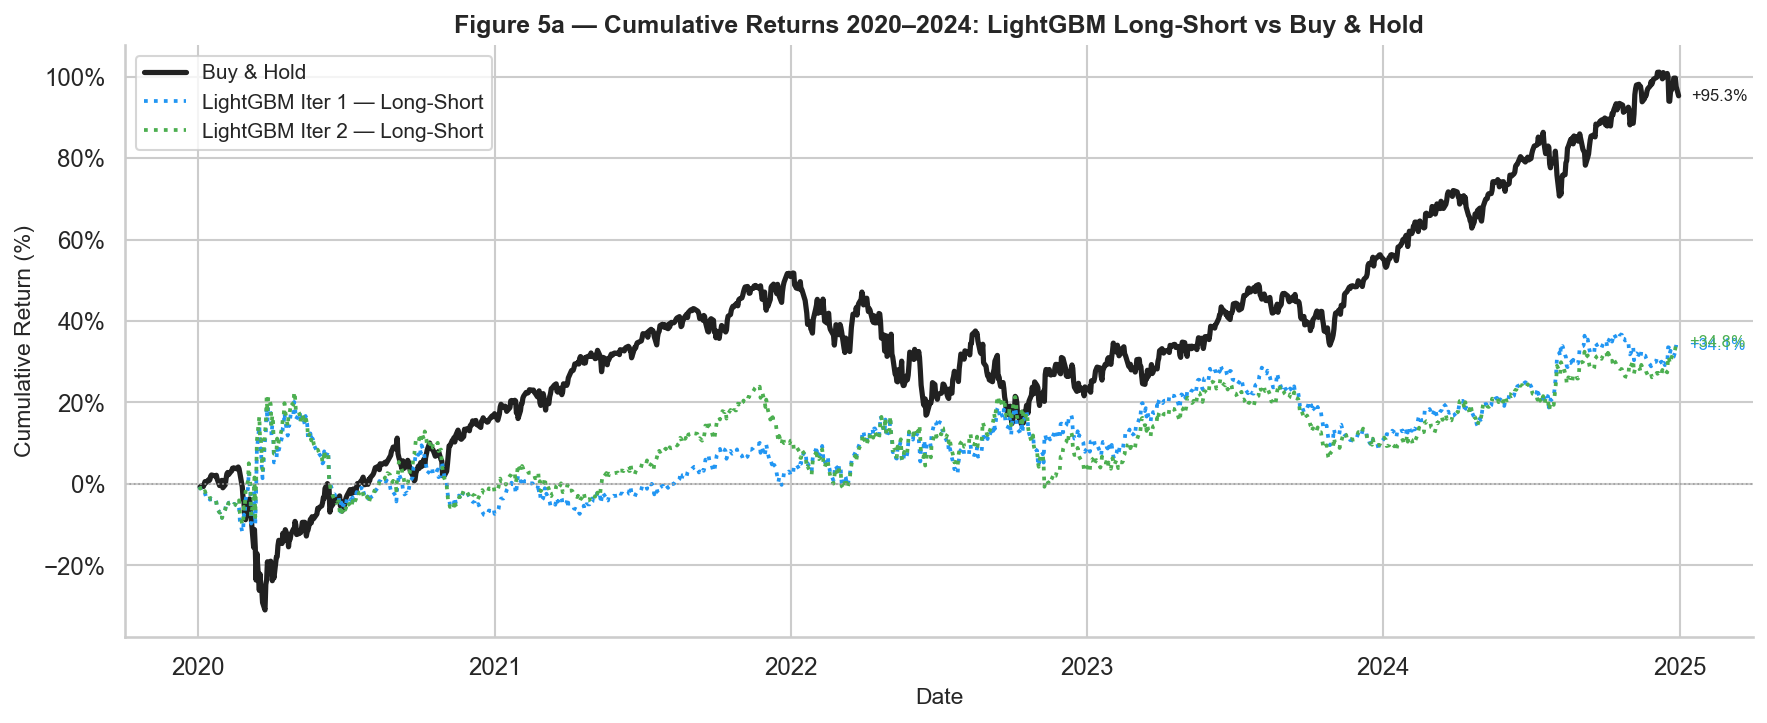

   Figure saved -> notes\notebook_figures\fig5b_ebmprimary_longshort.png


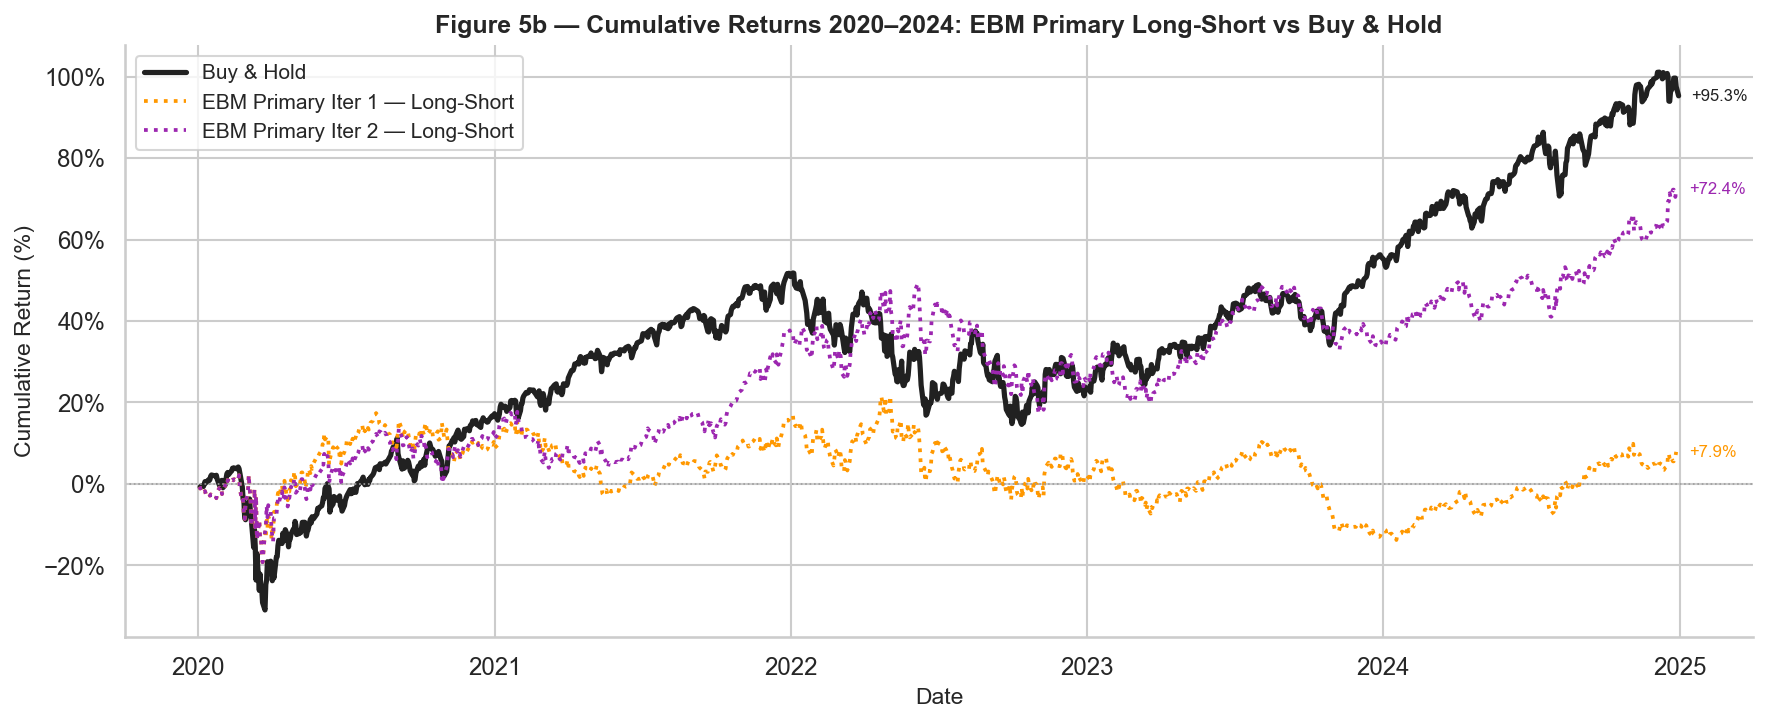

   Figure saved -> notes\notebook_figures\fig5c_lgbm_longonly.png


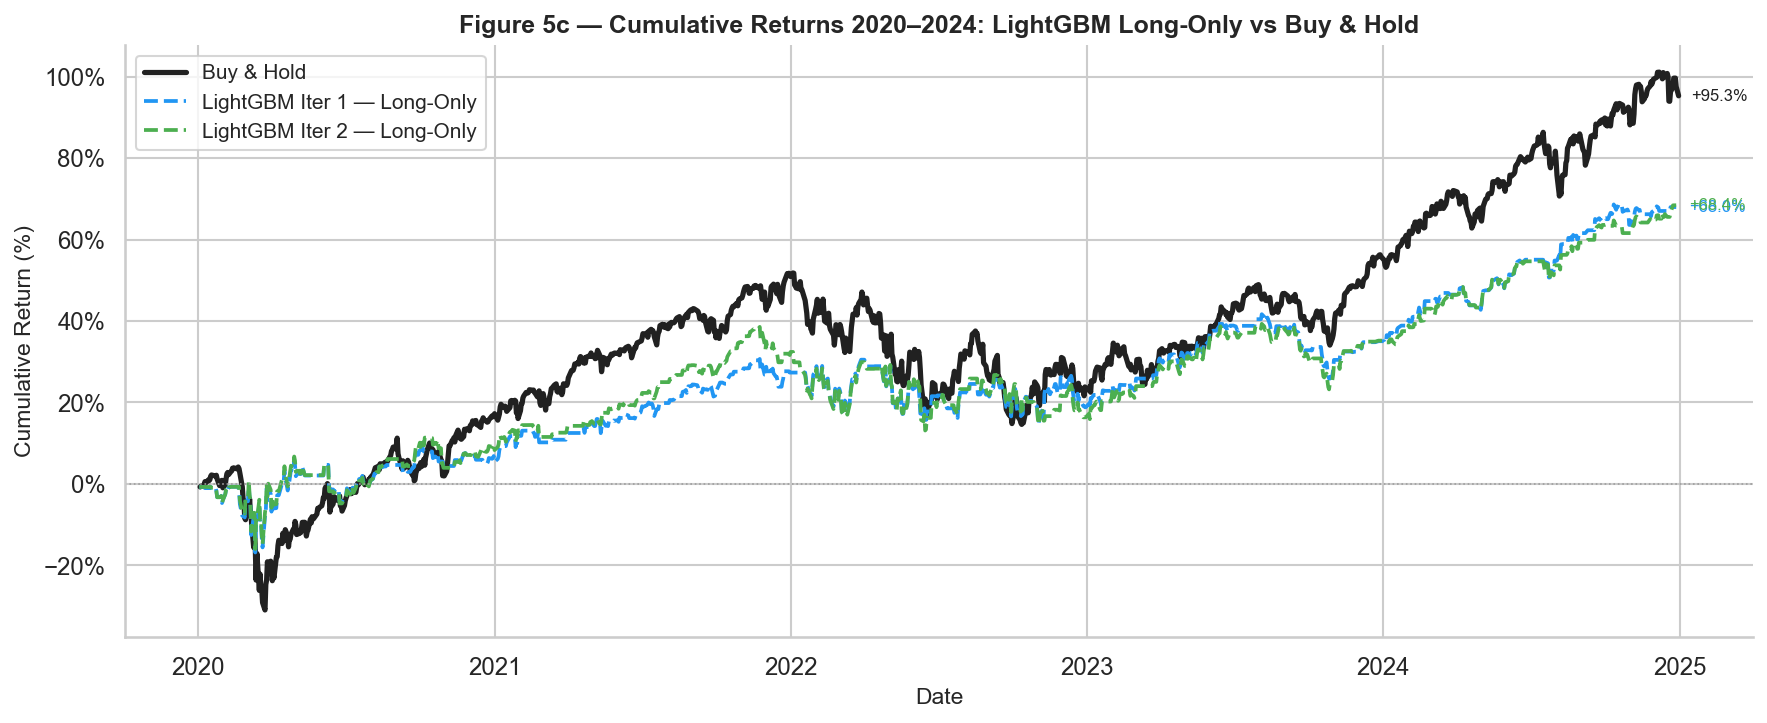

   Figure saved -> notes\notebook_figures\fig5d_ebmprimary_longonly.png


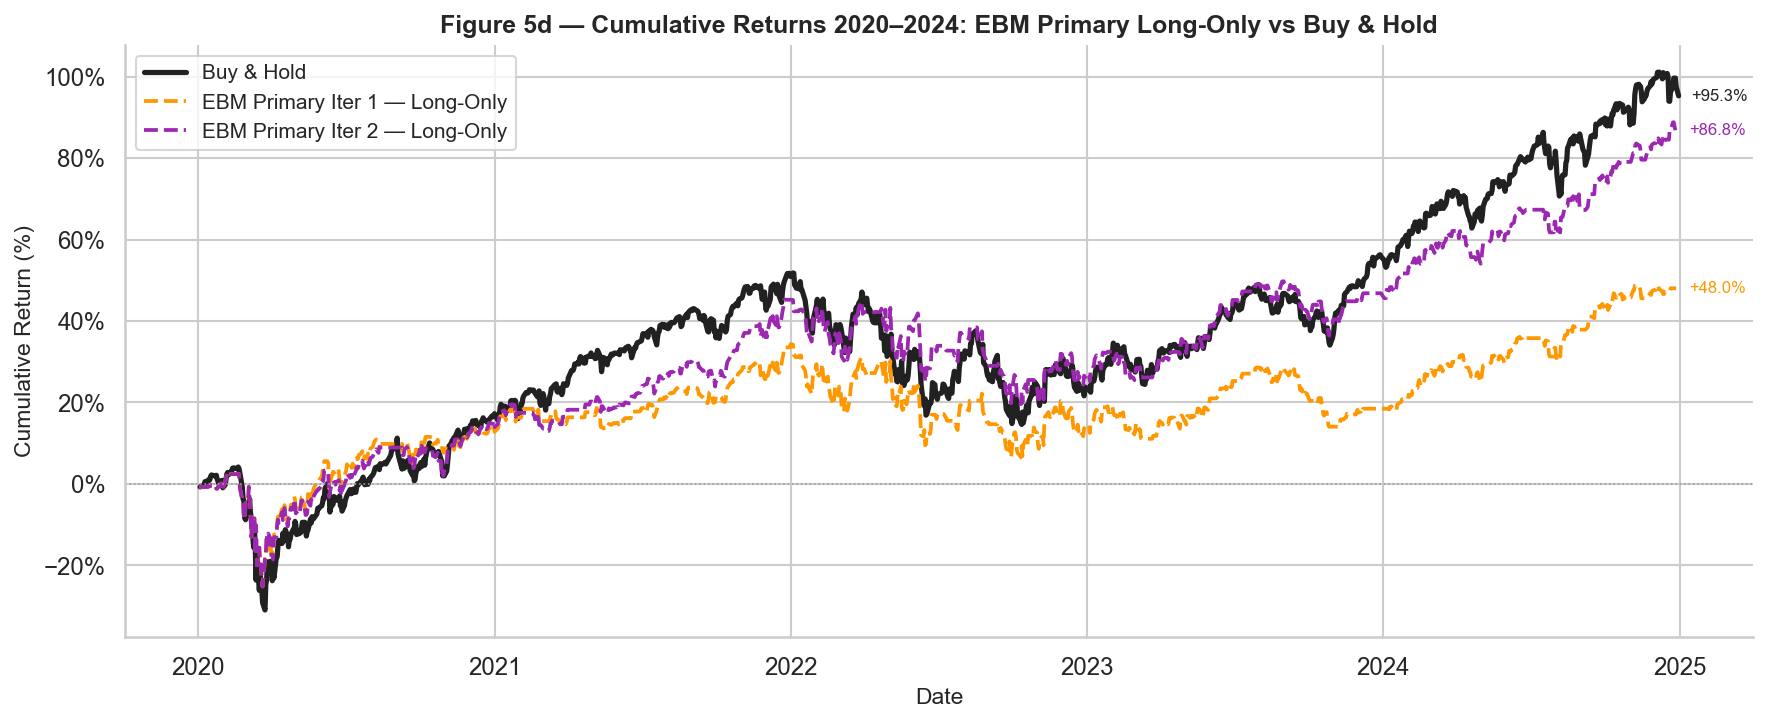

   Figure saved -> notes\notebook_figures\fig5e_lgbm_shortonly.png


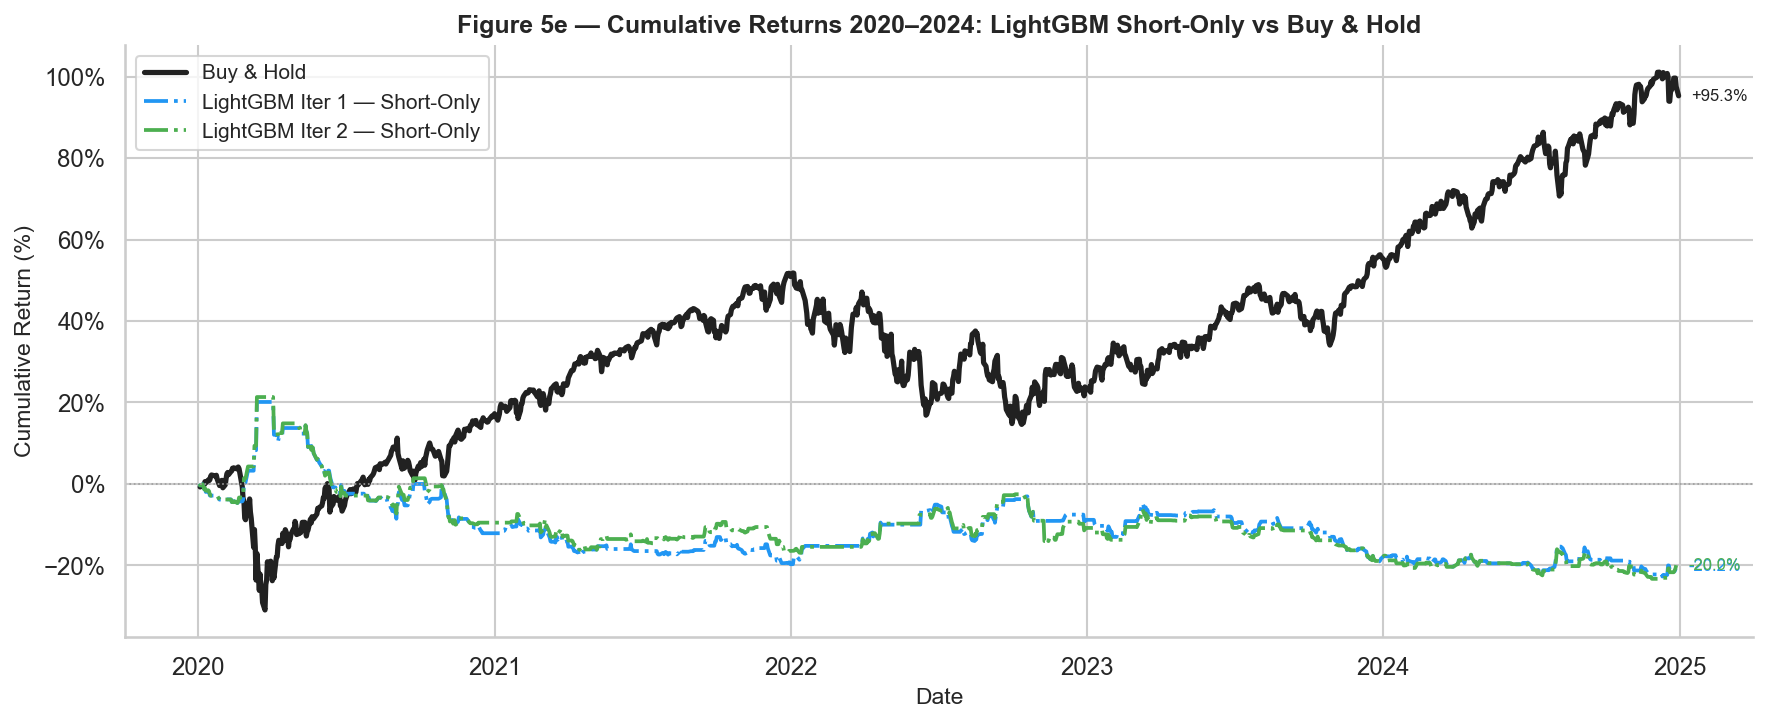

   Figure saved -> notes\notebook_figures\fig5f_ebmprimary_shortonly.png


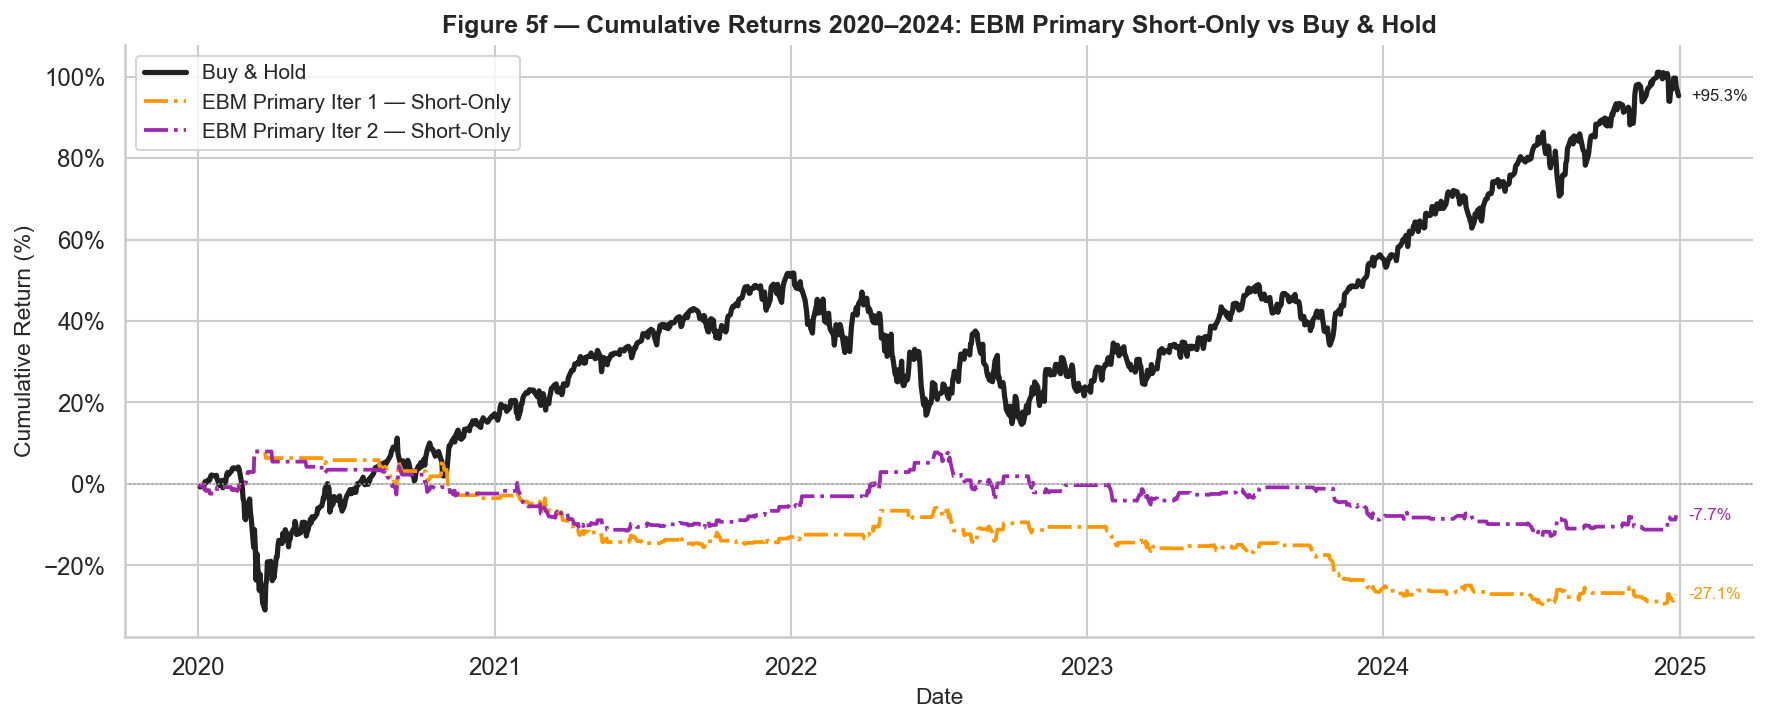

In [15]:
# ─── _build_curve (self-contained) ──────────────────────────────────────────
def _build_curve(fold_results, model_key, strategy='long_only'):
    _all_d, _all_r = [], []
    for fr in fold_results:
        td   = fr['SPY']['test_data']
        _m   = fr['SPY'].get(model_key)
        if _m is None:
            continue
        pred = _m['predictions']
        if 'ret_1d_forward' not in td.columns:
            continue
        ret = td['ret_1d_forward'].values
        n   = min(len(pred), len(ret))
        pred, ret = pred[:n], ret[:n]
        _nm = ~np.isnan(ret)
        pred, ret = pred[_nm], ret[_nm]
        try:
            _dates = (td.index.get_level_values('date')
                      if isinstance(td.index, pd.MultiIndex) else td.index)
            _dates = pd.DatetimeIndex(_dates)[:n][_nm]
        except Exception:
            _dates = pd.date_range('2020-01-01', periods=len(ret), freq='B')
        if strategy == 'long_short':
            _sigs = np.where(pred == 1, 1.0, -1.0)
        elif strategy == 'short_only':
            _sigs = np.where(pred == 0, -1.0, 0.0)
        else:  # long_only
            _sigs = pred.astype(float)
        _all_d.extend(_dates)
        _all_r.extend(_sigs * ret)
    if not _all_d:
        return None
    _s = pd.Series(_all_r, index=pd.DatetimeIndex(_all_d)).sort_index()
    return (1 + _s).cumprod()

# ─── Shared data ──────────────────────────────────────────────────────────────
_spy_ret_oos = None
if df_spy is not None and 'Close' in df_spy.columns:
    _spy_ret_oos = df_spy.loc['2020-01-01':'2024-12-31', 'Close'].pct_change().dropna()

PURPLE = '#9C27B0'

def _annotate_end(ax, curve, label, color):
    """Annotate the right end of a cumulative-return curve."""
    if curve is None:
        return
    _final     = float((curve.iloc[-1] - 1) * 100)
    _last_date = curve.index[-1]
    ax.annotate(f'{_final:+.1f}%',
                xy=(_last_date, _final),
                xytext=(6, 0), textcoords='offset points',
                fontsize=8, color=color, va='center')

def _plot_equity(curves_spec, title, figname, bh_curve):
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
    if bh_curve is not None:
        _n = (bh_curve - 1) * 100
        ax.plot(_n.index, _n, linestyle='-', color=BLACK, linewidth=2.5, label='Buy & Hold')
        _annotate_end(ax, bh_curve, 'Buy & Hold', BLACK)
    for _cv, _lbl, _col, _lsty in curves_spec:
        if _cv is None: continue
        _n = (_cv - 1) * 100
        ax.plot(_n.index, _n, linestyle=_lsty, color=_col, linewidth=1.8, label=_lbl)
        _annotate_end(ax, _cv, _lbl, _col)
    ax.axhline(0, color=GRAY, linewidth=0.8, linestyle=':')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Cumulative Return (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=10, loc='upper left')
    plt.tight_layout()
    save_fig(fig, figname)
    plt.show()

if oos is not None:
    _bh_curve = (1 + _spy_ret_oos).cumprod() if _spy_ret_oos is not None else None

    # ── Pre-build all curves ──────────────────────────────────────────────────
    _lgbm1_ls  = _build_curve(oos['iteration_1']['fold_results'], 'lightgbm',    'long_short')
    _lgbm2_ls  = _build_curve(oos['iteration_2']['fold_results'], 'lightgbm',    'long_short')
    _lgbm1_lo  = _build_curve(oos['iteration_1']['fold_results'], 'lightgbm',    'long_only')
    _lgbm2_lo  = _build_curve(oos['iteration_2']['fold_results'], 'lightgbm',    'long_only')
    _lgbm1_so  = _build_curve(oos['iteration_1']['fold_results'], 'lightgbm',    'short_only')
    _lgbm2_so  = _build_curve(oos['iteration_2']['fold_results'], 'lightgbm',    'short_only')
    _ebmp1_ls  = _build_curve(oos['iteration_1']['fold_results'], 'ebm_primary', 'long_short')
    _ebmp2_ls  = _build_curve(oos['iteration_2']['fold_results'], 'ebm_primary', 'long_short')
    _ebmp1_lo  = _build_curve(oos['iteration_1']['fold_results'], 'ebm_primary', 'long_only')
    _ebmp2_lo  = _build_curve(oos['iteration_2']['fold_results'], 'ebm_primary', 'long_only')
    _ebmp1_so  = _build_curve(oos['iteration_1']['fold_results'], 'ebm_primary', 'short_only')
    _ebmp2_so  = _build_curve(oos['iteration_2']['fold_results'], 'ebm_primary', 'short_only')

    # ── Figure 5a — LightGBM Long-Short ──────────────────────────────────────
    _plot_equity(
        [(_lgbm1_ls, 'LightGBM Iter 1 — Long-Short', BLUE,  ':'),
         (_lgbm2_ls, 'LightGBM Iter 2 — Long-Short', GREEN, ':')],
        'Figure 5a — Cumulative Returns 2020–2024: LightGBM Long-Short vs Buy & Hold',
        'fig5a_lgbm_longshort', _bh_curve)

    # ── Figure 5b — EBM Primary Long-Short ───────────────────────────────────
    _plot_equity(
        [(_ebmp1_ls, 'EBM Primary Iter 1 — Long-Short', ORANGE, ':'),
         (_ebmp2_ls, 'EBM Primary Iter 2 — Long-Short', PURPLE, ':')],
        'Figure 5b — Cumulative Returns 2020–2024: EBM Primary Long-Short vs Buy & Hold',
        'fig5b_ebmprimary_longshort', _bh_curve)

    # ── Figure 5c — LightGBM Long-Only ───────────────────────────────────────
    _plot_equity(
        [(_lgbm1_lo, 'LightGBM Iter 1 — Long-Only', BLUE,  '--'),
         (_lgbm2_lo, 'LightGBM Iter 2 — Long-Only', GREEN, '--')],
        'Figure 5c — Cumulative Returns 2020–2024: LightGBM Long-Only vs Buy & Hold',
        'fig5c_lgbm_longonly', _bh_curve)

    # ── Figure 5d — EBM Primary Long-Only ────────────────────────────────────
    _plot_equity(
        [(_ebmp1_lo, 'EBM Primary Iter 1 — Long-Only', ORANGE, '--'),
         (_ebmp2_lo, 'EBM Primary Iter 2 — Long-Only', PURPLE, '--')],
        'Figure 5d — Cumulative Returns 2020–2024: EBM Primary Long-Only vs Buy & Hold',
        'fig5d_ebmprimary_longonly', _bh_curve)

    # ── Figure 5e — LightGBM Short-Only ──────────────────────────────────────
    _plot_equity(
        [(_lgbm1_so, 'LightGBM Iter 1 — Short-Only', BLUE,  '-.'),
         (_lgbm2_so, 'LightGBM Iter 2 — Short-Only', GREEN, '-.')],
        'Figure 5e — Cumulative Returns 2020–2024: LightGBM Short-Only vs Buy & Hold',
        'fig5e_lgbm_shortonly', _bh_curve)

    # ── Figure 5f — EBM Primary Short-Only ───────────────────────────────────
    _plot_equity(
        [(_ebmp1_so, 'EBM Primary Iter 1 — Short-Only', ORANGE, '-.'),
         (_ebmp2_so, 'EBM Primary Iter 2 — Short-Only', PURPLE, '-.')],
        'Figure 5f — Cumulative Returns 2020–2024: EBM Primary Short-Only vs Buy & Hold',
        'fig5f_ebmprimary_shortonly', _bh_curve)

else:
    print('INFO: OOS data not available — equity curves skipped')

> **Figure 5a — LightGBM Long-Short:** The primary trading strategy: buy when the
> model predicts a price rise, short-sell when it predicts a decline. Both iterations
> achieve positive returns over 2020–2024: LightGBM Iter 1 (blue dotted) reaches
> **+34.1%** (Sharpe 0.39, MaxDD −23.2%) and Iter 2 (green dotted) **+34.8%**
> (Sharpe 0.39) — virtually identical, confirming that regime features add negligible
> financial value in the long-short strategy.

> **Figure 5b — EBM Primary Long-Short:** EBM Primary Iter 1 (orange dotted) achieves
> **+7.9%** (Sharpe 0.18) — positive but modest, reflecting a more conservative signal
> relative to LightGBM. EBM Primary Iter 2 (purple dotted) dramatically outperforms
> all other long-short strategies at **+72.4%** (Sharpe 0.63, MaxDD −21.5%), driven by
> regime features that improve directional timing in structured market environments.
> This is the strongest long-short result in the pipeline.

> **Figure 5c — LightGBM Long-Only:** The conservative variant: go to cash instead of
> shorting when the model is bearish. LightGBM Iter 1 (blue dashed) reaches **+68.0%**
> (Sharpe 0.69, MaxDD −16.6%), capturing a substantial portion of Buy & Hold's +95.3%
> gain while significantly reducing drawdown. LightGBM Iter 2 (green dashed) is nearly
> identical at **+68.4%** (Sharpe 0.70) — adding regime features neither helps nor
> hurts the long-only strategy materially.

> **Figure 5d — EBM Primary Long-Only:** EBM Primary Iter 1 (orange dashed) achieves
> **+48.0%** (Sharpe 0.51). EBM Primary Iter 2 (purple dashed) reaches **+86.8%**
> (Sharpe 0.75, MaxDD −27.0%) — matching Buy & Hold's Sharpe ratio while using an
> interpretable model. This is the best risk-adjusted result among all active
> strategies and the strongest argument for combining regime detection with
> interpretable models.

> **Figure 5e — LightGBM Short-Only:** The mirror of Long-Only: short SPY when the
> model predicts a decline, hold cash otherwise. Both iterations deliver negative
> Sharpe ratios (Iter 1: −0.31, Iter 2: −0.30), as the 2020–2024 bull market offers
> little room for short-biased strategies — down days are fewer and smaller than up
> days during this period.

> **Figure 5f — EBM Primary Short-Only:** EBM Primary Iter 1 (Sharpe −0.67) generates
> the most losses short-side, reflecting too many short signals during sustained
> rallies. EBM Primary Iter 2 (Sharpe −0.15) is the least negative across all models
> and strategies — regime features filter out false short signals during bull regimes,
> confirming the value of regime context even when the strategy itself is unfavourable.
> The clear gap between Long-Only and Short-Only Sharpe ratios across all models
> reflects the long bias in the training labels (55.7% positive) and the directional
> nature of the 2020–2024 market.

In [16]:
# ─── Execution Summary & Library Versions ─────────────────────────────────────
print('=' * 60)
print('NOTEBOOK EXECUTION COMPLETE')
print(f'Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 60)
print('\nLibrary versions:')
for _lib in ['numpy', 'pandas', 'matplotlib', 'seaborn',
             'sklearn', 'lightgbm', 'interpret', 'shap']:
    try:
        _mod = importlib.import_module(_lib)
        print(f'  {_lib:14s}: {getattr(_mod, "__version__", "unknown")}')
    except ImportError:
        print(f'  {_lib:14s}: not installed')
print(f'  {"python":14s}: {sys.version.split()[0]}')
print(f'\nFigures saved to : {FIG_DIR.resolve()}')
print(f'Figures generated: {len(list(FIG_DIR.glob("*.png")))}')

NOTEBOOK EXECUTION COMPLETE
Timestamp: 2026-05-18 14:59:25

Library versions:
  numpy         : 2.4.2
  pandas        : 3.0.1
  matplotlib    : 3.10.8
  seaborn       : 0.13.2
  sklearn       : 1.8.0
  lightgbm      : 4.6.0
  interpret     : 0.7.8
  shap          : 0.51.0
  python        : 3.14.0

Figures saved to : C:\Users\M333209\OneDrive - MerckGroup\Escritorio\TFM\Code\notes\notebook_figures
Figures generated: 21
